In [236]:
!python -m pip install geopy
!python.exe -m pip install --upgrade pip

In [237]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
import re
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    brier_score_loss)

In [238]:
df = pd.read_csv("weatherAUS_2026C1.csv")
df

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145407,145454,2017-06-20,Uluru,2.6,22.0,0.0,NaN,NaN,E,29.0,...,26.5,1024.8,1021.2,NaN,NaN,10.1,21.6,No,No,0.0
145408,145455,2017-06-21,Uluru,3.1,23.2,0.0,NaN,NaN,E,31.0,...,24.7,1024.3,1020.5,NaN,NaN,11.1,21.5,No,No,0.0
145409,145456,2017-06-22,Uluru,3.6,26.0,0.0,NaN,NaN,NNW,21.0,...,21.4,1023.3,1018.4,NaN,NaN,11.8,24.5,No,No,0.0
145410,145457,2017-06-23,Uluru,4.8,27.4,0.0,NaN,NaN,N,39.0,...,23.7,1021.0,1016.0,NaN,NaN,12.0,26.9,No,No,0.0


In [239]:
df = df.drop(columns="Unnamed: 0")

In [240]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'RainfallTomorrow'],
      dtype='str')

In [241]:
df.describe(include='all')

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
count,145412,145412,143928.000000,144159.000000,142152.000000,82658.000000,75616.000000,135096,135159.000000,134850,...,140907.000000,130351.000000,130388.000000,89542.000000,86076.000000,143646.000000,141805.000000,142152,142153,142153.000000
unique,3435,49,NaN,NaN,NaN,NaN,NaN,16,NaN,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,NaN
top,2013-03-01,Canberra,NaN,NaN,NaN,NaN,NaN,W,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,NaN
freq,49,3435,NaN,NaN,NaN,NaN,NaN,9910,NaN,11754,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110276,110281,NaN
mean,NaN,NaN,12.196528,23.223064,2.361516,5.468616,7.611241,NaN,40.036668,NaN,...,51.532206,1017.647237,1015.255080,4.447287,4.509770,16.991981,21.683360,NaN,NaN,2.361242
std,NaN,NaN,6.417956,7.135927,8.479338,4.193871,3.785612,NaN,13.648259,NaN,...,20.844414,7.113833,7.044507,2.887161,2.720306,6.509191,6.953072,NaN,NaN,8.479084
min,NaN,NaN,-9.700000,-5.100000,0.000000,0.000000,0.000000,NaN,6.000000,NaN,...,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,NaN,NaN,0.000000
25%,NaN,NaN,7.600000,17.900000,0.000000,2.600000,4.800000,NaN,31.000000,NaN,...,36.600000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,NaN,NaN,0.000000
50%,NaN,NaN,12.000000,22.600000,0.000000,4.800000,8.400000,NaN,38.000000,NaN,...,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,NaN,NaN,0.000000
75%,NaN,NaN,16.900000,28.200000,0.800000,7.400000,10.600000,NaN,48.000000,NaN,...,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,NaN,NaN,0.800000


De las columnas presentes se puede entender que representan lo siguiente:  
|Variable| Significado|
|-----|-----|
|unnamed | Esta columna debe ser el index original de la misma|
|Date | Fecha  |
|Location | Ubicación  |
|MinTemp | Temperatura Minima en ºC  |
|MaxTemp | Temperatura Máxima en ºC  |
|Rainfall | cantidad de lluvia en el periodo de 24hs en mm  |
|Evaporation | Evaporación de liquido en un recipiente abierto en un periodo de 24hs en mm  |
|Sunshine | cantidad de horas de sol en el día  |
|WindGustDir | Dirección de ráfagas de viento, expresada en dirección cardinal, se entiende que habla de ráfaga máxima   |
|WindGustSpeed | Velocidad del viento en esa ráfaga, expresada en km/h  |
|WindDir9am/3pm | Dirección del viento, expresada en dirección cardinal, en esos respectivos horarios  |
|WindSpeed9am/3pm | Velocidad del viento en esos respectivos horarios en km/h  |
|Humidity9am/3pm | Humedad en ese horario, en %  |
|Pressure9am/3pm | Presión atmosferica en ese horario, en hPa  |
|cloud9am/3pm | Variable Categorica que expresa tipo de Nube en ese momento  |
|Temp9am/3pm | Temperatura en ese horario, en ºC  |
|RainToday | si ha llovido hoy  |
|RainTomorrow | si va a llover mañana  |
|RainfallTomorrow | cuanta cantidad se espera de lluvia mañana?  |

Se ha usado información del Australian National Bureau of Meteorology para poder entender correctamente el significado de cada variable

In [242]:
df.isnull().sum()

Date                    0
Location                0
MinTemp              1484
MaxTemp              1253
Rainfall             3260
Evaporation         62754
Sunshine            69796
WindGustDir         10316
WindGustSpeed       10253
WindDir9am          10562
WindDir3pm           4226
WindSpeed9am         1767
WindSpeed3pm         3061
Humidity9am          2653
Humidity3pm          4505
Pressure9am         15061
Pressure3pm         15024
Cloud9am            55870
Cloud3pm            59336
Temp9am              1766
Temp3pm              3607
RainToday            3260
RainTomorrow         3259
RainfallTomorrow     3259
dtype: int64

Se observan demasiados datos NaN, por lo que se descarta la posibilidad de poder eliminarlo.

In [243]:
df.nunique()

Date                3435
Location              49
MinTemp              395
MaxTemp              506
Rainfall             681
Evaporation          358
Sunshine             145
WindGustDir           16
WindGustSpeed        120
WindDir9am            16
WindDir3pm            16
WindSpeed9am          76
WindSpeed3pm          75
Humidity9am          983
Humidity3pm          995
Pressure9am          547
Pressure3pm          542
Cloud9am              10
Cloud3pm              10
Temp9am              446
Temp3pm              503
RainToday              2
RainTomorrow           2
RainfallTomorrow     681
dtype: int64

In [244]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              145412 non-null  str    
 1   Location          145412 non-null  str    
 2   MinTemp           143928 non-null  float64
 3   MaxTemp           144159 non-null  float64
 4   Rainfall          142152 non-null  float64
 5   Evaporation       82658 non-null   float64
 6   Sunshine          75616 non-null   float64
 7   WindGustDir       135096 non-null  str    
 8   WindGustSpeed     135159 non-null  float64
 9   WindDir9am        134850 non-null  str    
 10  WindDir3pm        141186 non-null  str    
 11  WindSpeed9am      143645 non-null  float64
 12  WindSpeed3pm      142351 non-null  float64
 13  Humidity9am       142759 non-null  float64
 14  Humidity3pm       140907 non-null  float64
 15  Pressure9am       130351 non-null  float64
 16  Pressure3pm       130388 non-nu

In [245]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df = df.drop(columns=["Date"])


# Tipo de variables en el dataset:
|Tipo|Variables|
|----|-----|
|Numéricas|MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustSpeed WindSpeed9am. WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Temp9am, Temp3pm|
|Categóricas|Location, WindGustDir, WindDir9am, WindDirs3pm, Cloud9am, Cloud3pm, RainToday, RainfallTomorrow|
|Temporales|Year, Month, Day|
|Target|RainTomorrow|


In [246]:
df["RainTomorrow"].value_counts(normalize=True)

RainTomorrow
No     0.775791
Yes    0.224209
Name: proportion, dtype: float64

<Axes: xlabel='RainTomorrow', ylabel='count'>

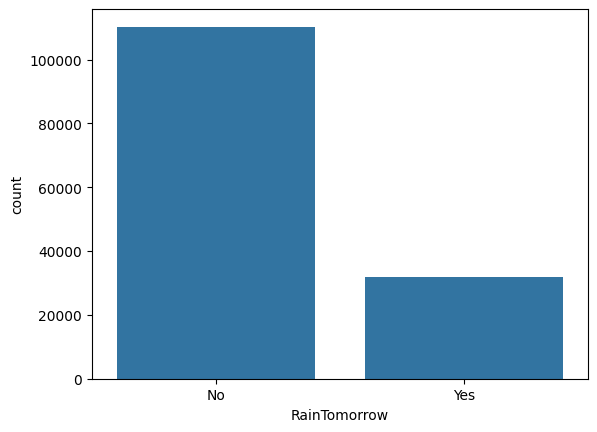

In [247]:
sns.countplot(x="RainTomorrow", data=df)

Existe desbalanceo moderado entre clases, Se pregunta por ello para que tengamos en cuenta que métricas utilizar a la hora de calificar el modelo. Por ejemplo, si nuestro modelo fuera simplemente "RainTomorrow = 0", este en cada ejecucíon indicaría que no llueve, y así tendría una Accuracy del 77.57% a pesar de no ser una resolución funciona, al saber que la variable target está desbalanceada debemos aplicar otras métricas evaluar el rendimiento.

In [248]:
df.drop_duplicates(inplace=True)

In [249]:
def faltantes(data: pd.DataFrame) -> pd.DataFrame:
    faltantes = data.isnull().sum()
    porcentaje = (faltantes / len(df)) * 100

    return porcentaje
faltantes(df)

Location             0.000000
MinTemp              1.020549
MaxTemp              0.861690
Rainfall             2.241906
Evaporation         43.155998
Sunshine            47.998790
WindGustDir          7.094325
WindGustSpeed        7.051000
WindDir9am           7.263500
WindDir3pm           2.906225
WindSpeed9am         1.215168
WindSpeed3pm         2.105053
Humidity9am          1.824471
Humidity3pm          3.098094
Pressure9am         10.357467
Pressure3pm         10.332022
Cloud9am            38.421863
Cloud3pm            40.805436
Temp9am              1.214480
Temp3pm              2.480538
RainToday            2.241906
RainTomorrow         2.241218
RainfallTomorrow     2.241218
Year                 0.000000
Month                0.000000
Day                  0.000000
dtype: float64

se observa una perdida de casi la mitad de los datos en las variables Cloud, Sunshine y Evaporación. Se procede a borrar el 2% de entries de RainTomorrow, ya que imputarlos introduciría error al modelo.

In [250]:
df = df.dropna(subset=["RainTomorrow"])
faltantes(df)

Location             0.000000
MinTemp              0.448109
MaxTemp              0.226516
Rainfall             0.989075
Evaporation         42.779259
Sunshine            47.684537
WindGustDir          6.561944
WindGustSpeed        6.519736
WindDir9am           7.041005
WindDir3pm           2.656293
WindSpeed9am         0.948274
WindSpeed3pm         1.849416
Humidity9am          1.247951
Humidity3pm          2.538814
Pressure9am          9.855578
Pressure3pm          9.832364
Cloud9am            37.734694
Cloud3pm            40.151105
Temp9am              0.635935
Temp3pm              1.916949
RainToday            0.989075
RainTomorrow         0.000000
RainfallTomorrow     0.000000
Year                 0.000000
Month                0.000000
Day                  0.000000
dtype: float64

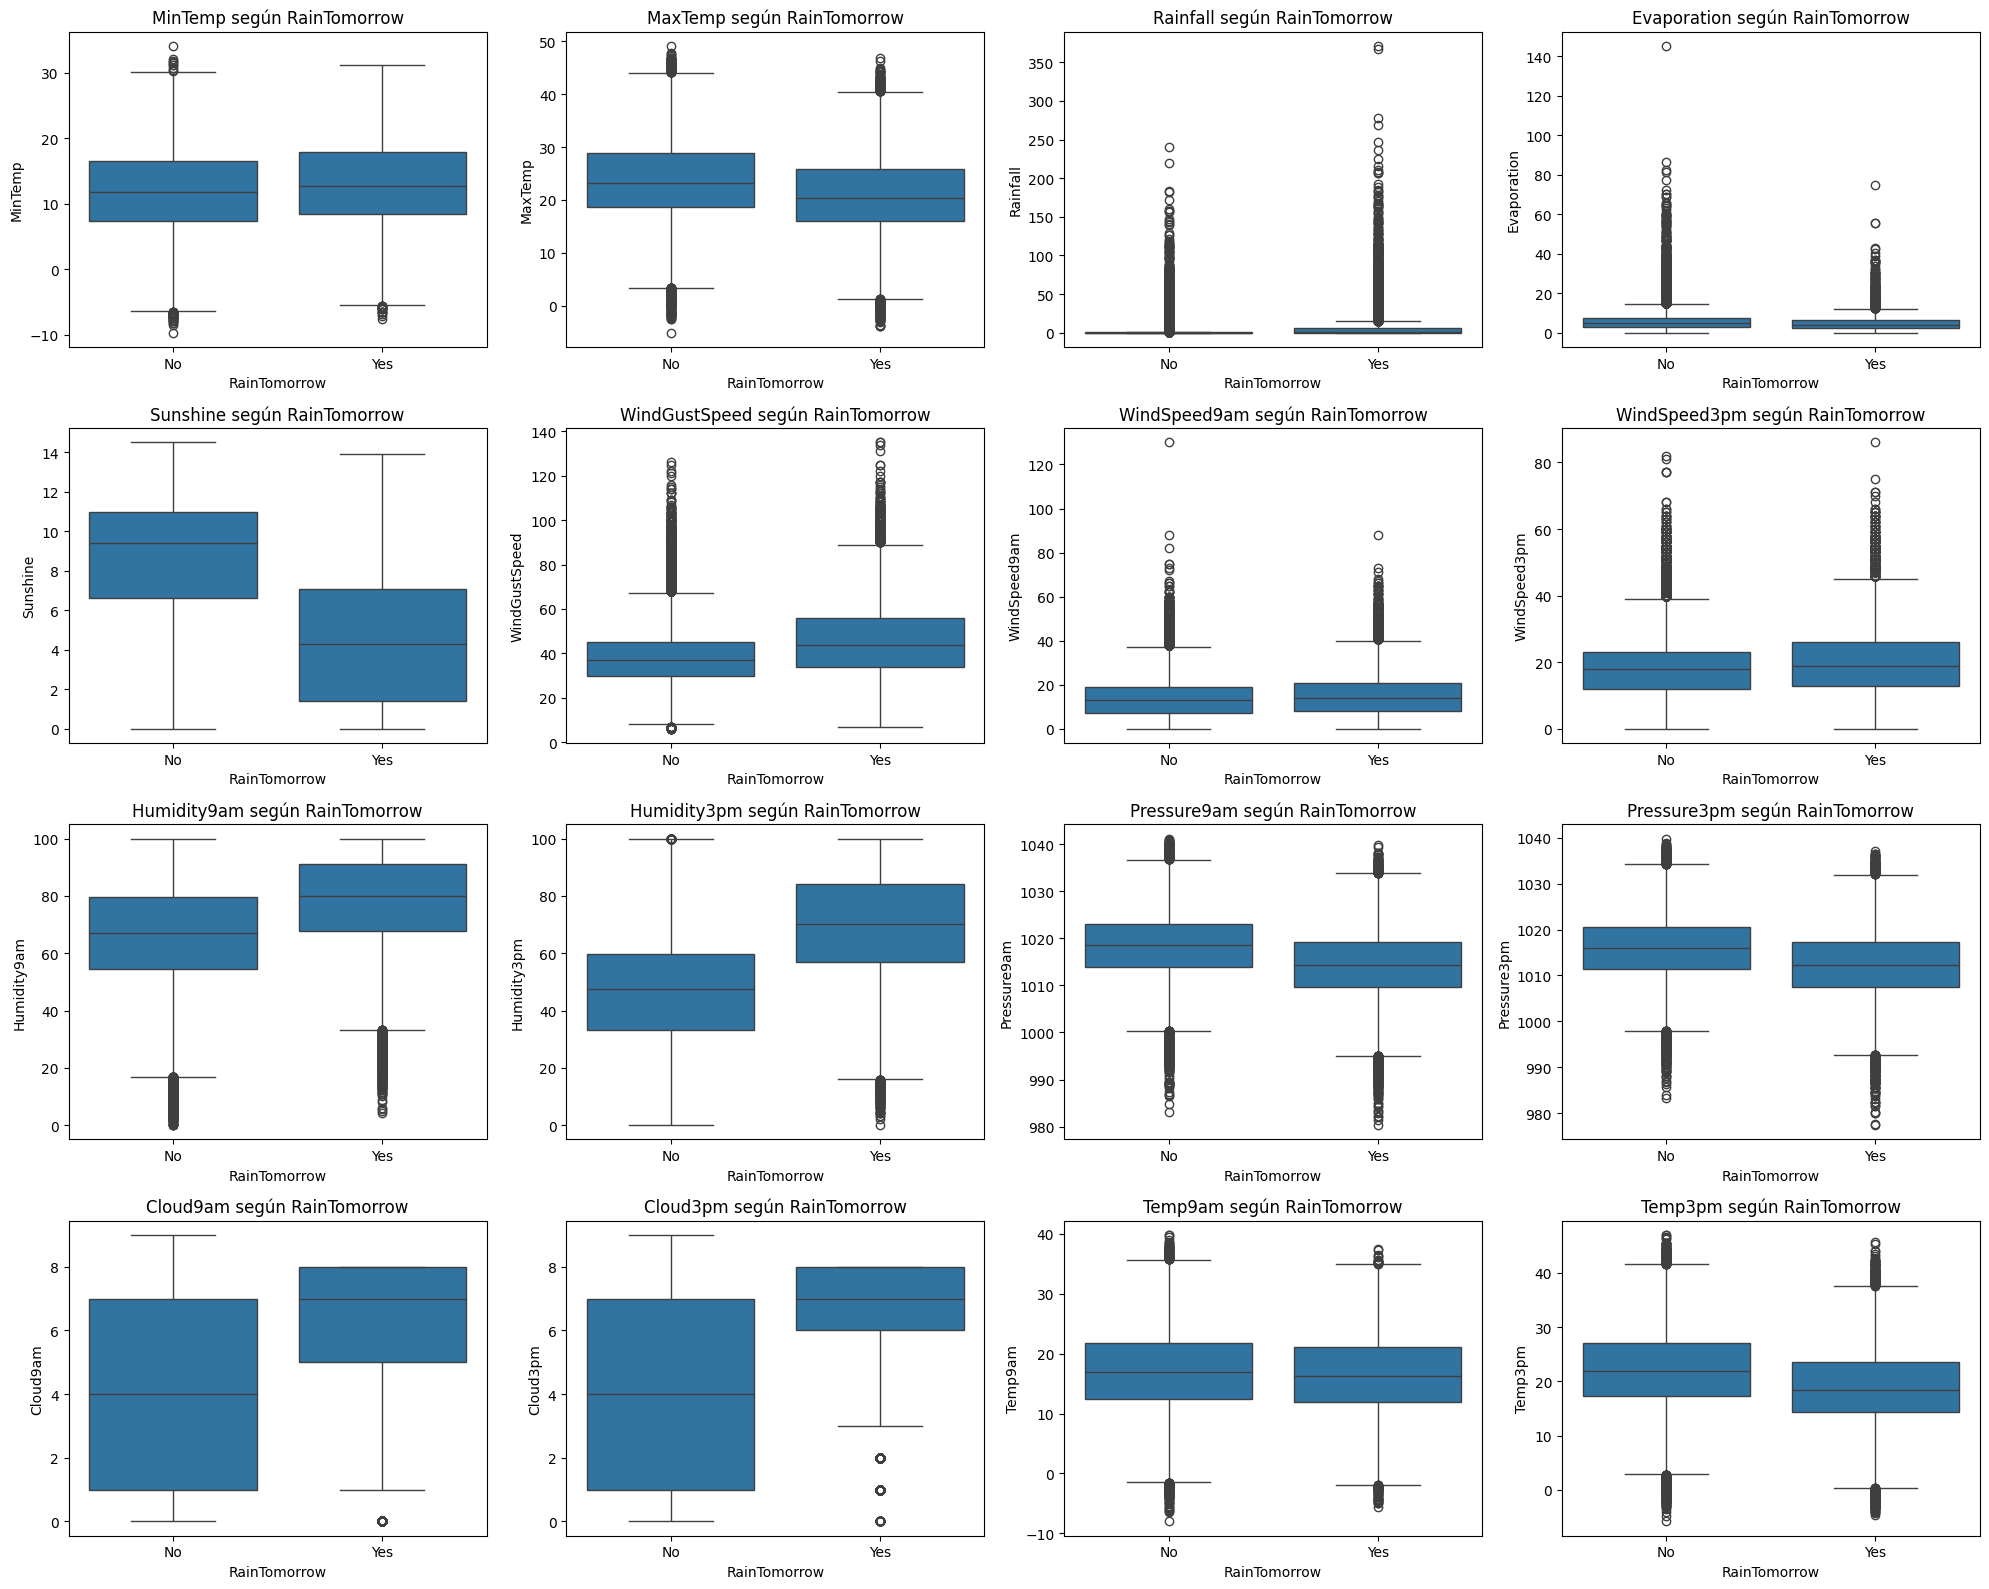

In [251]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Variables numéricas a comparar contra RainTomorrow
num_cols = [
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "Evaporation",
    "Sunshine",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Humidity9am",
    "Humidity3pm",
    "Pressure9am",
    "Pressure3pm",
    "Cloud9am",
    "Cloud3pm",
    "Temp9am",
    "Temp3pm"]

num_cols = [col for col in num_cols if col in df.columns]

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(
        data=df,
        x="RainTomorrow",
        y=col
    )
    plt.title(f"{col} según RainTomorrow")
    plt.xlabel("RainTomorrow")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

Los boxplots muestran diferencias claras entre los días en los que llueve al día siguiente (`RainTomorrow = Yes`) y aquellos en los que no. Los días previos a lluvia presentan mayor `Humidity3pm`, `Humidity9am`, `Cloud9am`, `Cloud3pm`, `WindGustSpeed` y `Rainfall`, mientras que muestran menor `Sunshine`, `Pressure9am`, `Pressure3pm`, `MaxTemp` y `Temp3pm`.

In [252]:
cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
        'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
        'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am',
        'Temp3pm']

def resumen_distribuciones(df):

    resumen = {}

    for col in cols:

        serie = df[col].dropna()

        Q1 = serie.quantile(0.25)
        Q3 = serie.quantile(0.75)

        resumen[col] = {
            "mean": serie.mean(),
            "median": serie.median(),
            "std": serie.std(),
            "var": serie.var(),
            "min": serie.min(),
            "max": serie.max(),
            "IQR": Q3 - Q1,
            "skew": serie.skew(),
            "kurtosis": serie.kurtosis(),
            "missing_pct": df[col].isnull().mean() * 100
        }

    resumen_df = pd.DataFrame(resumen).T

    return resumen_df   

In [253]:
distribuciones_previo = resumen_distribuciones(df)
distribuciones_previo


,mean,median,std,var,min,max,IQR,skew,kurtosis,missing_pct
MinTemp,12.188866,12.0,6.422856,41.253084,-9.7,34.1,9.2,0.022221,-0.481609,0.448109
MaxTemp,23.228596,22.6,7.134436,50.900172,-5.1,49.1,10.3,0.222679,-0.235140,0.226516
Rainfall,2.350461,0.0,8.466267,71.677678,0.0,371.0,0.8,9.886866,179.957216,0.989075
Evaporation,5.470149,4.8,4.188649,17.544780,0.0,145.0,4.8,3.746758,45.066745,42.779259
Sunshine,7.624919,8.5,3.781656,14.300920,0.0,14.5,5.7,-0.502936,-0.820411,47.684537
WindGustSpeed,39.985807,38.0,13.630314,185.785461,6.0,135.0,17.0,0.866666,1.401362,6.519736
WindSpeed9am,14.025219,13.0,8.914326,79.465210,0.0,130.0,12.0,0.785296,1.220041,0.948274
WindSpeed3pm,18.636901,18.0,8.858849,78.479205,0.0,86.0,12.0,0.619921,0.741008,1.849416
Humidity9am,68.824619,69.9,19.085026,364.238205,0.0,100.0,26.2,-0.484886,-0.044226,1.247951
Humidity3pm,51.475886,51.9,20.846540,434.578228,0.0,100.0,29.1,0.032263,-0.509691,2.538814


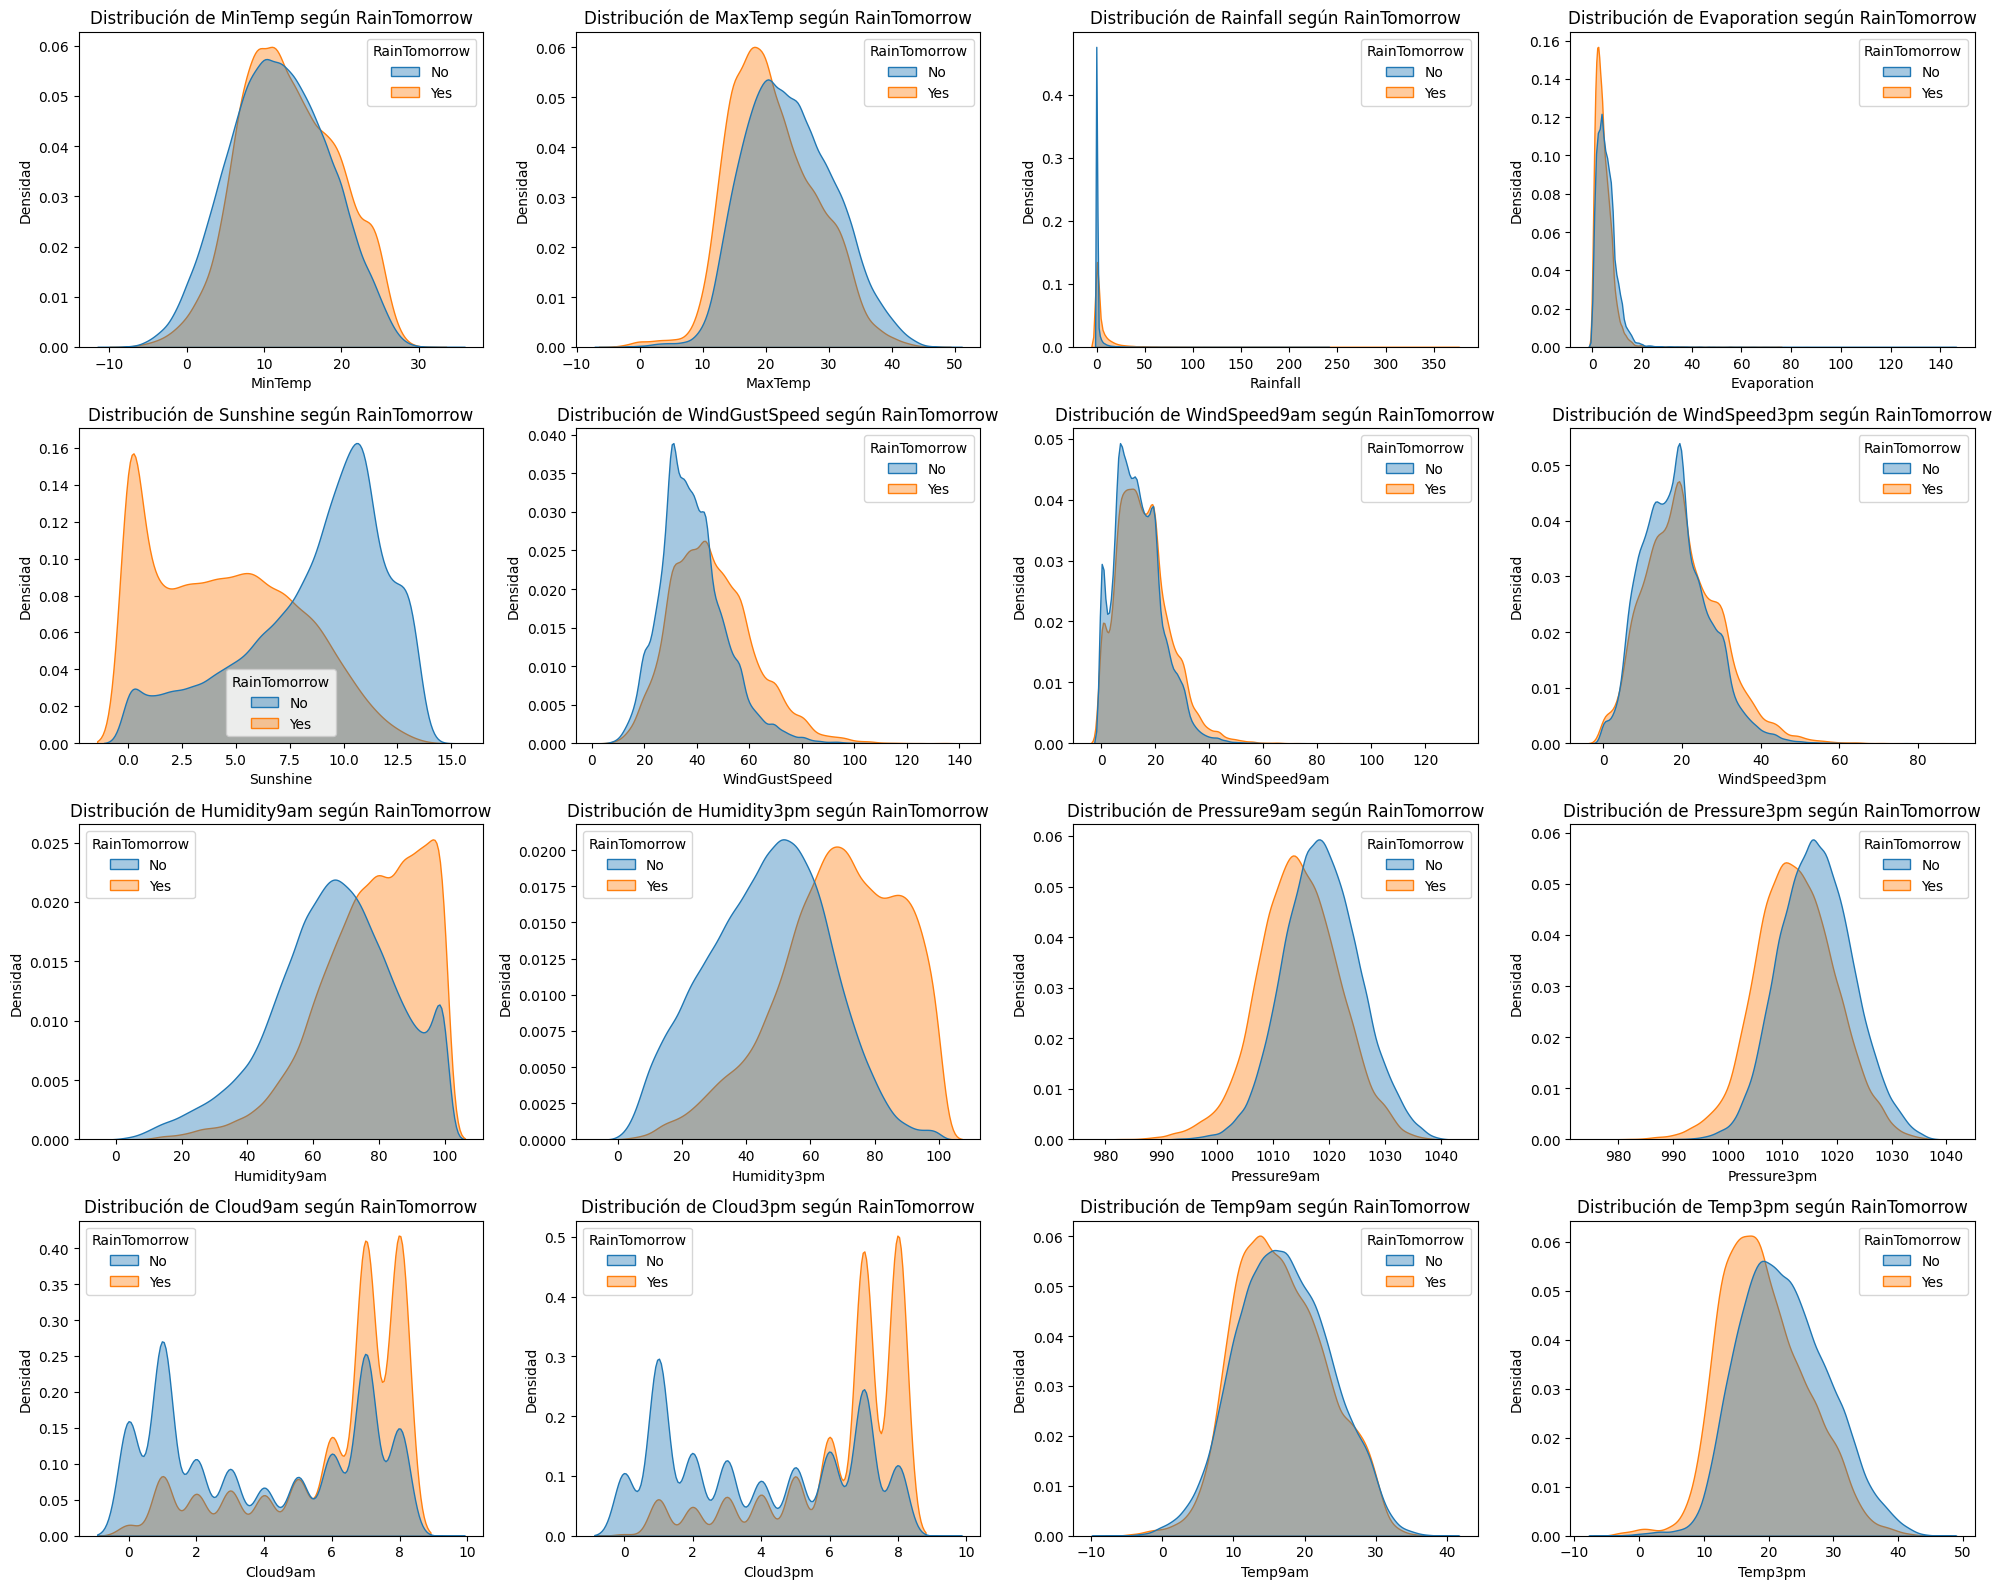

In [254]:
plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.kdeplot(
        data=df,
        x=col,
        hue="RainTomorrow",
        fill=True,
        common_norm=False,
        alpha=0.4
    )
    plt.title(f"Distribución de {col} según RainTomorrow")
    plt.xlabel(col)
    plt.ylabel("Densidad")

plt.tight_layout()
plt.show()

Las distribuciones por clase refuerzan lo observado en los boxplots: los días con `RainTomorrow = Yes` tienden a concentrarse en condiciones de mayor humedad, mayor nubosidad y mayor intensidad de viento. Las diferencias más marcadas aparecen en `Humidity3pm`, `Humidity9am`, `Cloud9am`, `Cloud3pm`, `Sunshine`, `Pressure9am` y `Pressure3pm`. En particular, los días previos a lluvia muestran valores más altos de humedad y nubosidad, menor cantidad de horas de sol y presiones atmosféricas más bajas. También se observa que `WindGustSpeed` presenta una distribución desplazada hacia valores mayores cuando al día siguiente llueve, lo que sugiere que ráfagas más intensas pueden estar asociadas a cambios meteorológicos previos a precipitaciones. En cambio, variables como `MinTemp`, `Temp9am` y `Evaporation` presentan mayor superposición entre clases, por lo que individualmente parecen tener menor poder discriminante.

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns

#Armamos una función que analice los nan de una columna

def Analizar_Var(df: pd.DataFrame ,col: str):

    print(f"ANÁLISIS DE NaN -> {col}")

    nan_pct = df[col].isnull().mean() * 100

    print(f"\n% faltantes total: {nan_pct:.2f}%")

    #Cálculo de los faltantes por ubicación y mes

    nan_flag = f"{col}_nan"

    df[nan_flag] = df[col].isnull()

    print("\n% NaN por Lugar:")

    display(
        (
            df.groupby("Location")[col]
            .apply(lambda x: x.isnull().mean() * 100)
            .sort_values(ascending=False)
            .to_frame("% NaN")
        )
    )


    print("\n% NaN por mes:")

    display(
        (
            df.groupby("Month")[col]
            .apply(lambda x: x.isnull().mean() * 100)
            .sort_values(ascending=False)
            .to_frame("% NaN")
        )
    )


    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x="RainTomorrow",
        hue=nan_flag
    )

    plt.title(f"NaN de {col} según RainTomorrow")

    plt.show()

ANÁLISIS DE NaN -> Evaporation

% faltantes total: 42.78%

% NaN por Lugar:


,% NaN
Location,
Albury,100.000000
Ballarat,100.000000
BadgerysCreek,100.000000
GoldCoast,100.000000
PearceRAAF,100.000000
Witchcliffe,100.000000
Wollongong,100.000000
Walpole,100.000000
Uluru,100.000000



% NaN por mes:


,% NaN
Month,
6,44.311280
5,44.113367
4,43.499027
1,43.402213
12,43.395005
2,43.087886
3,42.712488
10,42.316164
11,42.273798


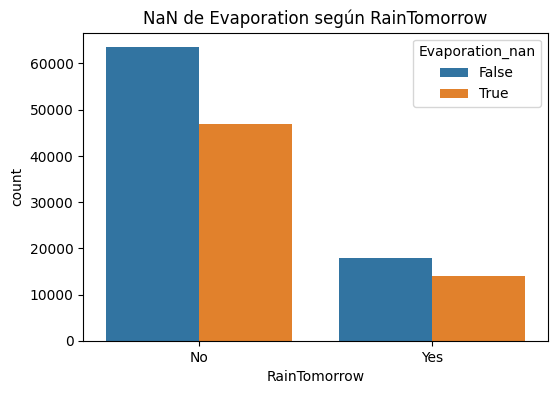

In [256]:
Analizar_Var(df,"Evaporation")

ANÁLISIS DE NaN -> Cloud9am

% faltantes total: 37.73%

% NaN por Lugar:


,% NaN
Location,
Adelaide,100.000000
BadgerysCreek,100.000000
Dartmoor,100.000000
GoldCoast,100.000000
Walpole,100.000000
Nhil,100.000000
NorahHead,100.000000
Penrith,100.000000
MountGinini,100.000000



% NaN por mes:


,% NaN
Month,
12,39.232192
1,39.029487
10,38.622501
5,38.284182
4,38.209800
3,38.071494
11,38.024605
2,38.014252
9,37.091230


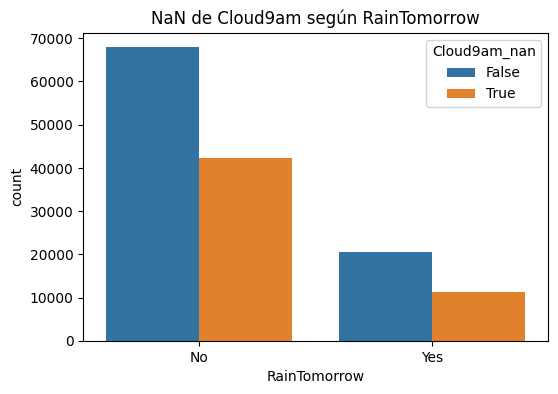

In [257]:
Analizar_Var(df,"Cloud9am")

ANÁLISIS DE NaN -> Cloud3pm

% faltantes total: 40.15%

% NaN por Lugar:


,% NaN
Location,
Adelaide,100.000000
BadgerysCreek,100.000000
Dartmoor,100.000000
GoldCoast,100.000000
Walpole,100.000000
Nhil,100.000000
NorahHead,100.000000
Penrith,100.000000
MountGinini,100.000000



% NaN por mes:


,% NaN
Month,
1,42.179398
12,42.118409
2,41.292162
11,41.270395
10,41.070823
5,40.773650
3,40.349801
4,40.084911
6,39.233946


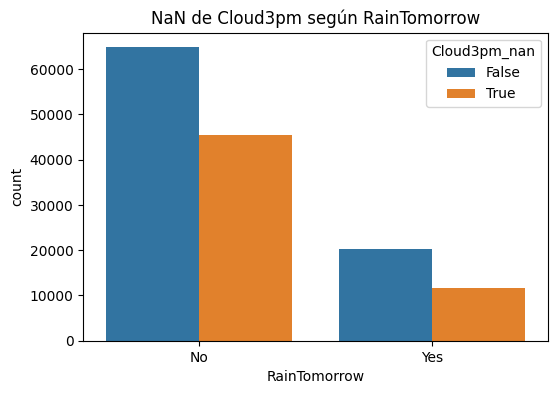

In [258]:
Analizar_Var(df,"Cloud3pm")

ANÁLISIS DE NaN -> Sunshine

% faltantes total: 47.68%

% NaN por Lugar:


,% NaN
Location,
Albury,100.000000
GoldCoast,100.000000
BadgerysCreek,100.000000
Bendigo,100.000000
Ballarat,100.000000
Katherine,100.000000
Wollongong,100.000000
Walpole,100.000000
Uluru,100.000000



% NaN por mes:


,% NaN
Month,
5,50.072769
6,49.283343
12,48.390379
4,48.337166
8,47.287876
10,47.280583
1,47.117096
11,47.011605
2,47.002375


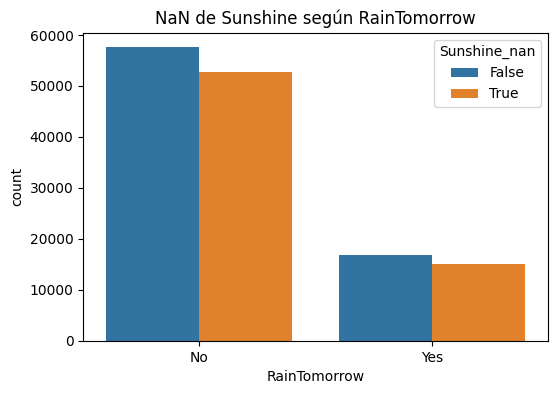

In [259]:
Analizar_Var(df,"Sunshine")

Se observa que algunas ciudades presentan una gran cantidad de valores faltantes en determinadas variables. Esto podría deberse a que ciertos observatorios no cuentan con los sensores necesarios para registrar esas mediciones. Por este motivo, se decidió imputar teniendo en cuenta que cuando los valores faltantes son esporádicos se imputen utilizando como referencia los datos disponibles del mismo lugar y del mismo mes, en cambio, cuando una variable no fue registrada de forma sistemática en una ciudad, se estima su valor a partir del promedio de observatorios cercanos. De esta manera, se busca conservar la mayor cantidad posible de información sin ignorar el contexto geográfico y estacional de los datos.

In [260]:
geolocator = Nominatim(user_agent="weatherAUS_imputation")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

coords = []

lugares = df["Location"].unique().tolist()

for loc in lugares:
    query = loc
    query = query.replace("Airport", " Airport")
    query = re.sub(r'(?<!^)(?=[A-Z])', ' ', loc)
    query = query.replace(" R A A F", " RAAF")
    

    place = geocode(f"{query}, Australia")

    coords.append({
        "Location": loc,
        "Latitude": place.latitude if place else np.nan,
        "Longitude": place.longitude if place else np.nan
    })

lugares_coords = pd.DataFrame(coords)

lugares_coords

,Location,Latitude,Longitude
0,Albury,-36.073773,146.913526
1,BadgerysCreek,-33.883145,150.742466
2,Cobar,-31.966663,145.304505
3,CoffsHarbour,-30.298600,153.109412
4,Moree,-29.461720,149.840715
5,Newcastle,-32.919295,151.779535
6,NorahHead,-33.281667,151.567778
7,NorfolkIsland,-29.032804,167.948314
8,Penrith,-33.751195,150.694171
9,Richmond,-37.807450,144.990721


In [261]:
coords_rad = np.radians(
    lugares_coords[["Latitude", "Longitude"]]
)

nn = NearestNeighbors(
    n_neighbors=6,
    metric="haversine"
)

nn.fit(coords_rad)

distances, indices = nn.kneighbors(coords_rad)

vecinos_dict = {}

for i, loc in enumerate(lugares_coords["Location"]):
    vecinos = lugares_coords.iloc[indices[i]]["Location"].tolist()
    vecinos = [v for v in vecinos if v != loc]
    vecinos_dict[loc] = vecinos

vecinos_dict

{'Albury': ['WaggaWagga', 'MountGinini', 'Tuggeranong', 'Canberra', 'Sale'],
 'BadgerysCreek': ['Penrith',
  'SydneyAirport',
  'Sydney',
  'Wollongong',
  'NorahHead'],
 'Cobar': ['Mildura', 'WaggaWagga', 'Albury', 'MountGinini', 'Canberra'],
 'CoffsHarbour': ['GoldCoast',
  'Williamtown',
  'Brisbane',
  'Newcastle',
  'Moree'],
 'Moree': ['CoffsHarbour',
  'Brisbane',
  'GoldCoast',
  'Williamtown',
  'Newcastle'],
 'Newcastle': ['Williamtown',
  'NorahHead',
  'Sydney',
  'SydneyAirport',
  'Penrith'],
 'NorahHead': ['Newcastle',
  'Williamtown',
  'Sydney',
  'SydneyAirport',
  'Penrith'],
 'NorfolkIsland': ['GoldCoast',
  'CoffsHarbour',
  'Brisbane',
  'Williamtown',
  'Newcastle'],
 'Penrith': ['BadgerysCreek',
  'Sydney',
  'SydneyAirport',
  'Wollongong',
  'NorahHead'],
 'Richmond': ['Melbourne',
  'Watsonia',
  'MelbourneAirport',
  'Ballarat',
  'Bendigo'],
 'Sydney': ['SydneyAirport',
  'BadgerysCreek',
  'Penrith',
  'Wollongong',
  'NorahHead'],
 'SydneyAirport': ['Sydn

In [262]:
def imputar_por_vecinos_geograficos(df, col, neighbors_dict):
    df = df.copy()

    # Promedio por mes y mismo lugar
    df[col] = df[col].fillna(
        df.groupby(["Location", "Month"])[col].transform("median")
    )

    # Promedio por mes y vecinos
    for loc, vecinos in neighbors_dict.items():

        for month in df.loc[
            (df["Location"] == loc) & (df[col].isnull()),
            "Month"
        ].unique():

            mask = (
                (df["Location"] == loc) &
                (df["Month"] == month) &
                (df[col].isnull())
            )

            valores_vecinos = df[
                (df["Location"].isin(vecinos)) &
                (df["Month"] == month)
            ][col].dropna()

            if len(valores_vecinos) > 0:
                df.loc[mask, col] = valores_vecinos.median()

    return df

In [263]:
def imputar_categoricas_por_vecinos_geograficos(
    df,
    col,
    neighbors_dict
):
    df = df.copy()

    def obtener_moda(serie):

        serie = serie.dropna()

        if len(serie) == 0:
            return np.nan

        moda = serie.mode()

        if len(moda) == 0:
            return np.nan

        return moda.iloc[0]

    #Promedio por mes y mismo lugar

    valores_grupo = (
        df.groupby(["Location", "Month"])[col]
        .transform(obtener_moda)
    )

    df[col] = df[col].fillna(valores_grupo)

    # Promedio por mes y vecinos

    for loc, vecinos in neighbors_dict.items():

        meses_faltantes = df.loc[
            (df["Location"] == loc) &
            (df[col].isnull()),
            "Month"
        ].unique()

        for month in meses_faltantes:

            mask = (
                (df["Location"] == loc) &
                (df["Month"] == month) &
                (df[col].isnull())
            )

            valores_vecinos = df[
                (df["Location"].isin(vecinos)) &
                (df["Month"] == month)
            ][col]

            moda_vecinos = obtener_moda(valores_vecinos)

            if not pd.isna(moda_vecinos):
                df.loc[mask, col] = moda_vecinos

    return df

Funciones auxiliares para imputar vecinos de variables tanto categóricas y numéricas con criterio de comparar datos en el mismo mes

In [264]:
cols_numericas = [
        'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
        'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
        'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
        'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

for col in cols_numericas:
    df = imputar_por_vecinos_geograficos(
        df,
        col,
        vecinos_dict
    )
    
cols_categoricas = [
    "WindGustDir",
    "WindDir9am",
    "WindDir3pm",
    "RainToday"
]

for col in cols_categoricas:

    df = imputar_categoricas_por_vecinos_geograficos(
        df,
        col,
        vecinos_dict
    )

faltantes(df)

Location            0.0
MinTemp             0.0
MaxTemp             0.0
Rainfall            0.0
Evaporation         0.0
Sunshine            0.0
WindGustDir         0.0
WindGustSpeed       0.0
WindDir9am          0.0
WindDir3pm          0.0
WindSpeed9am        0.0
WindSpeed3pm        0.0
Humidity9am         0.0
Humidity3pm         0.0
Pressure9am         0.0
Pressure3pm         0.0
Cloud9am            0.0
Cloud3pm            0.0
Temp9am             0.0
Temp3pm             0.0
RainToday           0.0
RainTomorrow        0.0
RainfallTomorrow    0.0
Year                0.0
Month               0.0
Day                 0.0
Evaporation_nan     0.0
Cloud9am_nan        0.0
Cloud3pm_nan        0.0
Sunshine_nan        0.0
dtype: float64

In [265]:
distribuciones_post = resumen_distribuciones(df)
distribuciones_post

,mean,median,std,var,min,max,IQR,skew,kurtosis,missing_pct
MinTemp,12.191591,12.0,6.420897,41.227919,-9.7,34.1,9.2,0.021019,-0.480639,0.0
MaxTemp,23.229223,22.6,7.131740,50.861715,-5.1,49.1,10.3,0.222769,-0.233954,0.0
Rainfall,2.327810,0.0,8.427368,71.020525,0.0,371.0,0.6,9.933117,181.622180,0.0
Evaporation,5.161116,4.6,3.540328,12.533922,0.0,145.0,4.4,3.750076,52.388743,0.0
Sunshine,7.956474,8.4,3.065199,9.395448,0.0,14.5,3.9,-0.703797,0.126794,0.0
WindGustSpeed,39.923790,38.0,13.215843,174.658500,6.0,135.0,16.0,0.901432,1.673499,0.0
WindSpeed9am,14.001745,13.0,8.891199,79.053412,0.0,130.0,12.0,0.788128,1.236964,0.0
WindSpeed3pm,18.563565,18.0,8.838095,78.111930,0.0,86.0,12.0,0.621971,0.750676,0.0
Humidity9am,68.935447,70.0,19.065762,363.503266,0.0,100.0,26.2,-0.490890,-0.040904,0.0
Humidity3pm,51.545627,52.1,20.746585,430.420791,0.0,100.0,28.9,0.020088,-0.500871,0.0


In [266]:
diferencia = distribuciones_post - distribuciones_previo

diferencia

,mean,median,std,var,min,max,IQR,skew,kurtosis,missing_pct
MinTemp,0.002725,0.0,-0.001959,-0.025165,0.0,0.0,0.000000e+00,-0.001201,0.000970,-0.448109
MaxTemp,0.000627,0.0,-0.002696,-0.038457,0.0,0.0,0.000000e+00,0.000090,0.001186,-0.226516
Rainfall,-0.022651,0.0,-0.038899,-0.657153,0.0,0.0,-2.000000e-01,0.046252,1.664963,-0.989075
Evaporation,-0.309033,-0.2,-0.648321,-5.010858,0.0,0.0,-4.000000e-01,0.003318,7.321999,-42.779259
Sunshine,0.331555,-0.1,-0.716456,-4.905472,0.0,0.0,-1.800000e+00,-0.200861,0.947205,-47.684537
WindGustSpeed,-0.062017,0.0,-0.414471,-11.126961,0.0,0.0,-1.000000e+00,0.034766,0.272138,-6.519736
WindSpeed9am,-0.023475,0.0,-0.023128,-0.411799,0.0,0.0,0.000000e+00,0.002832,0.016923,-0.948274
WindSpeed3pm,-0.073336,0.0,-0.020754,-0.367274,0.0,0.0,0.000000e+00,0.002050,0.009668,-1.849416
Humidity9am,0.110828,0.1,-0.019264,-0.734939,0.0,0.0,7.105427e-15,-0.006005,0.003321,-1.247951
Humidity3pm,0.069741,0.2,-0.099955,-4.157438,0.0,0.0,-2.000000e-01,-0.012176,0.008820,-2.538814


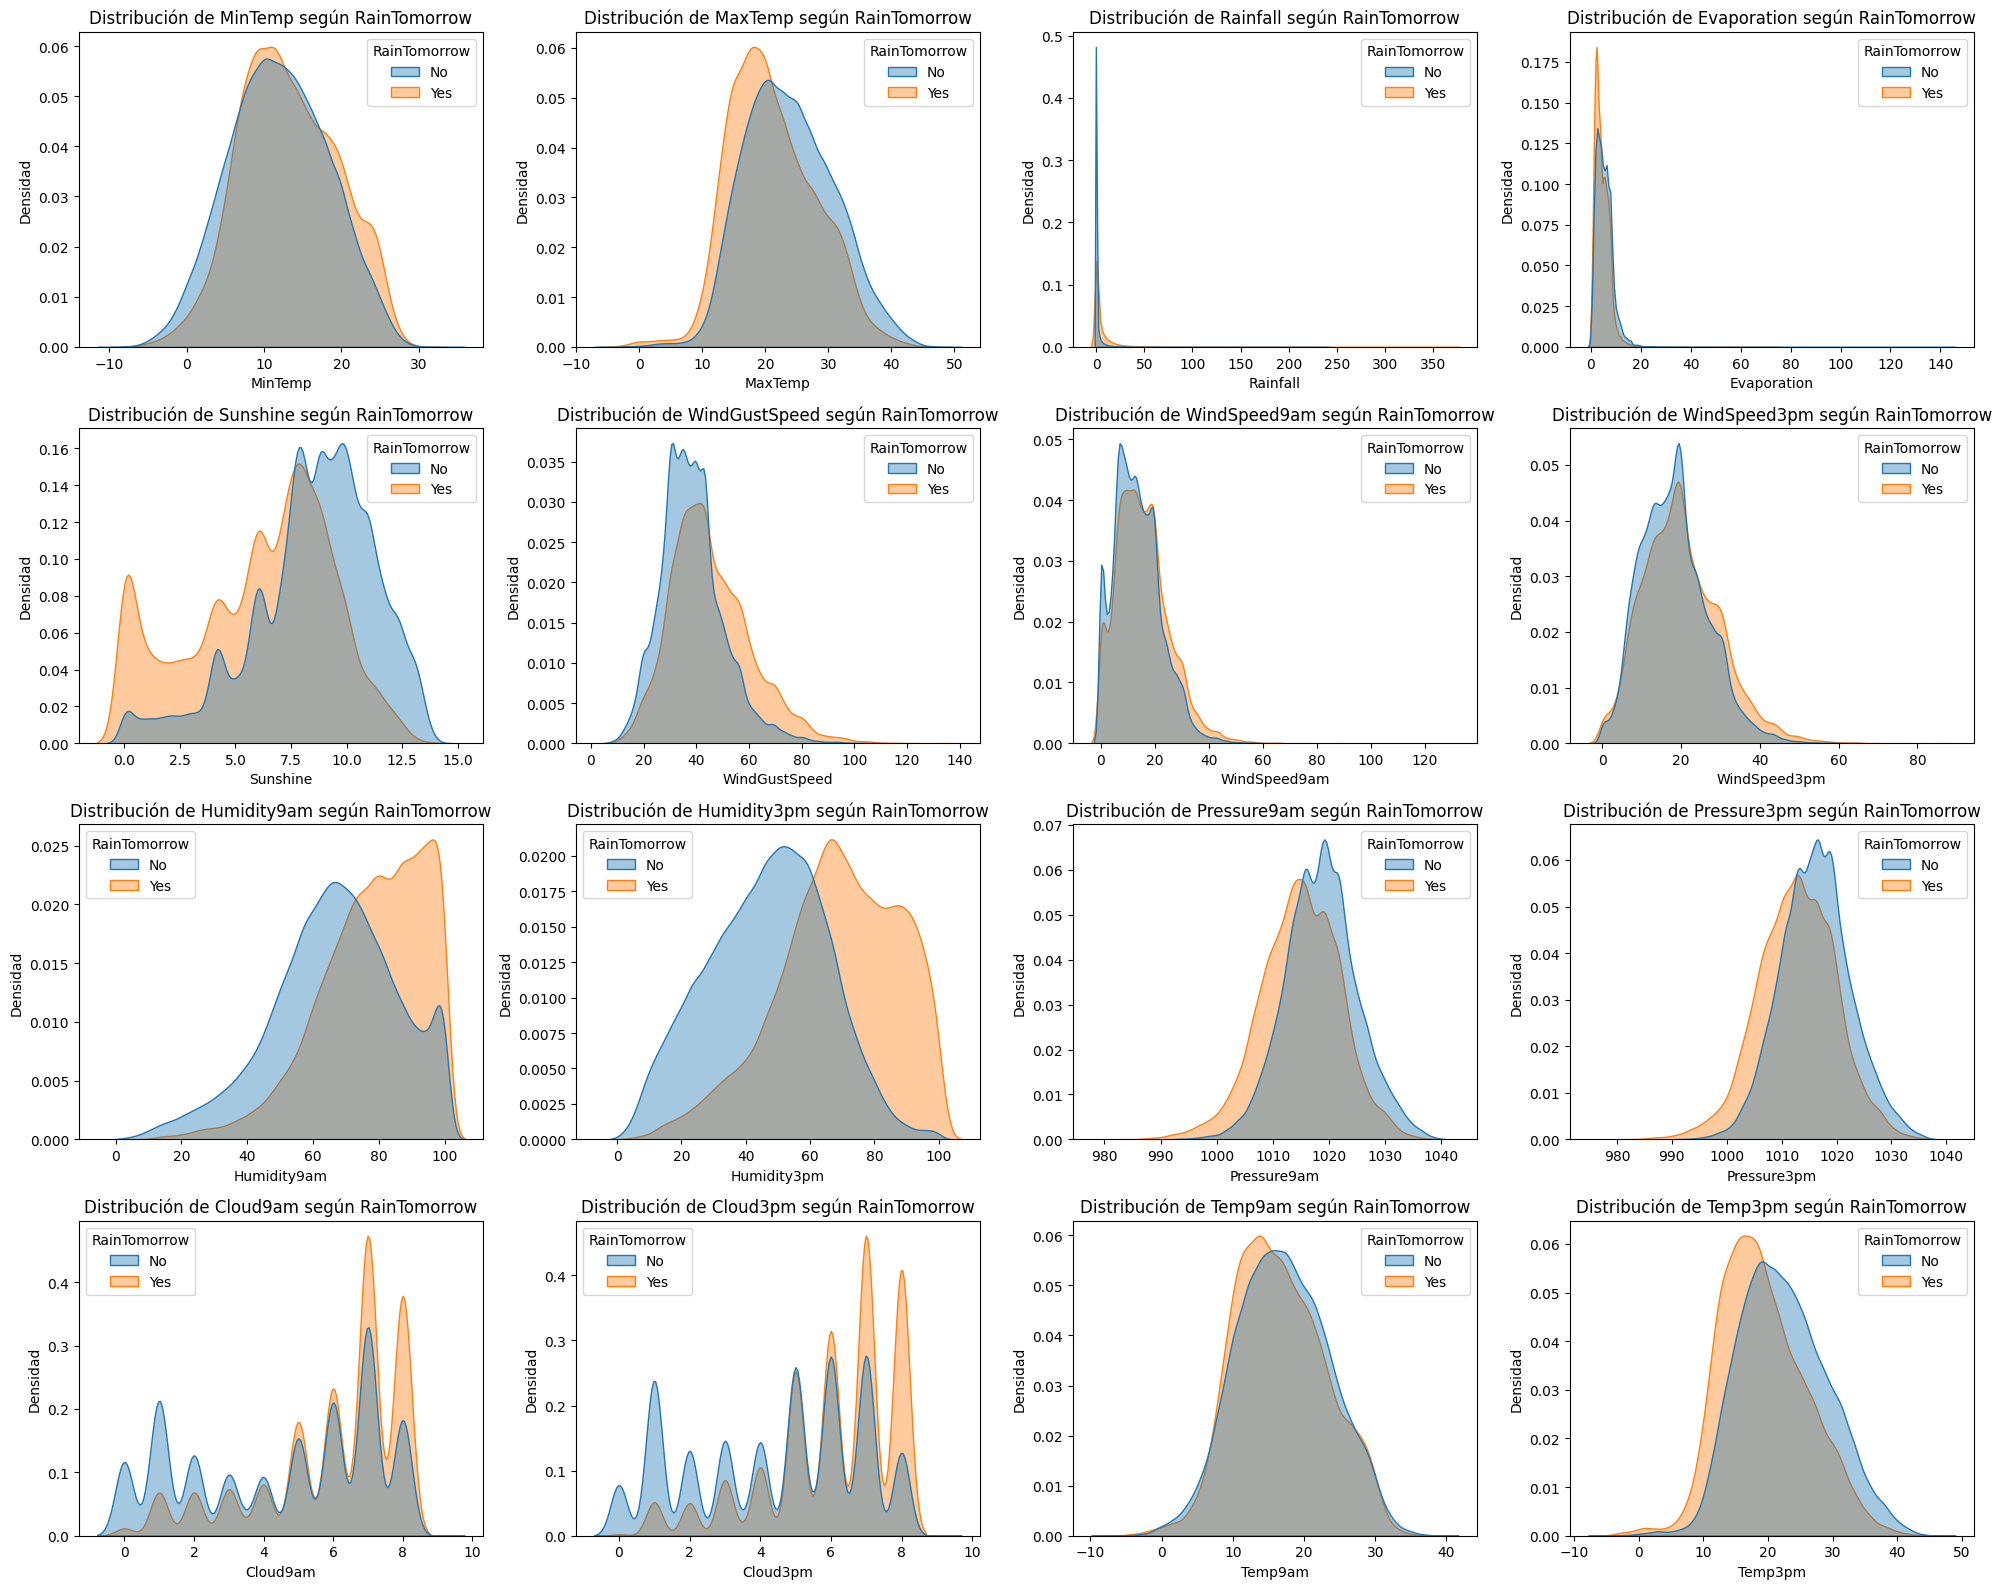

In [267]:
plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.kdeplot(
        data=df,
        x=col,
        hue="RainTomorrow",
        fill=True,
        common_norm=False,
        alpha=0.4
    )
    plt.title(f"Distribución de {col} según RainTomorrow")
    plt.xlabel(col)
    plt.ylabel("Densidad")

plt.tight_layout()
plt.show()

Al mirar las gráficas de distribución de datos de las variables, podemos notar que estas no cambiaron mucho luego de la imputación de datos, así que se considera que no se introdujo ruido en los datos, excepto por Evaporation, dónde varió mucho la Kurtosis (explicación de la métrica). 
En primer lugar, al mirar los boxplots se logra apreciar que no es muy explicativa de la variable Target, sumado a eso que sólo se tenían un 67% de los datos y que al imputarlos, el método elegido añadió bastante ruido se toma la decisión de eliminar la variable por miedo a introducir ruido innecesario al modelo.

In [268]:
# Se asigna un valor binario a las variables "yes/no"
df["RainToday"] = (
    df["RainToday"]
    .map({"No": 0, "Yes": 1})
)

df["RainTomorrow"] = (
    df["RainTomorrow"]
    .map({"No": 0, "Yes": 1})
)

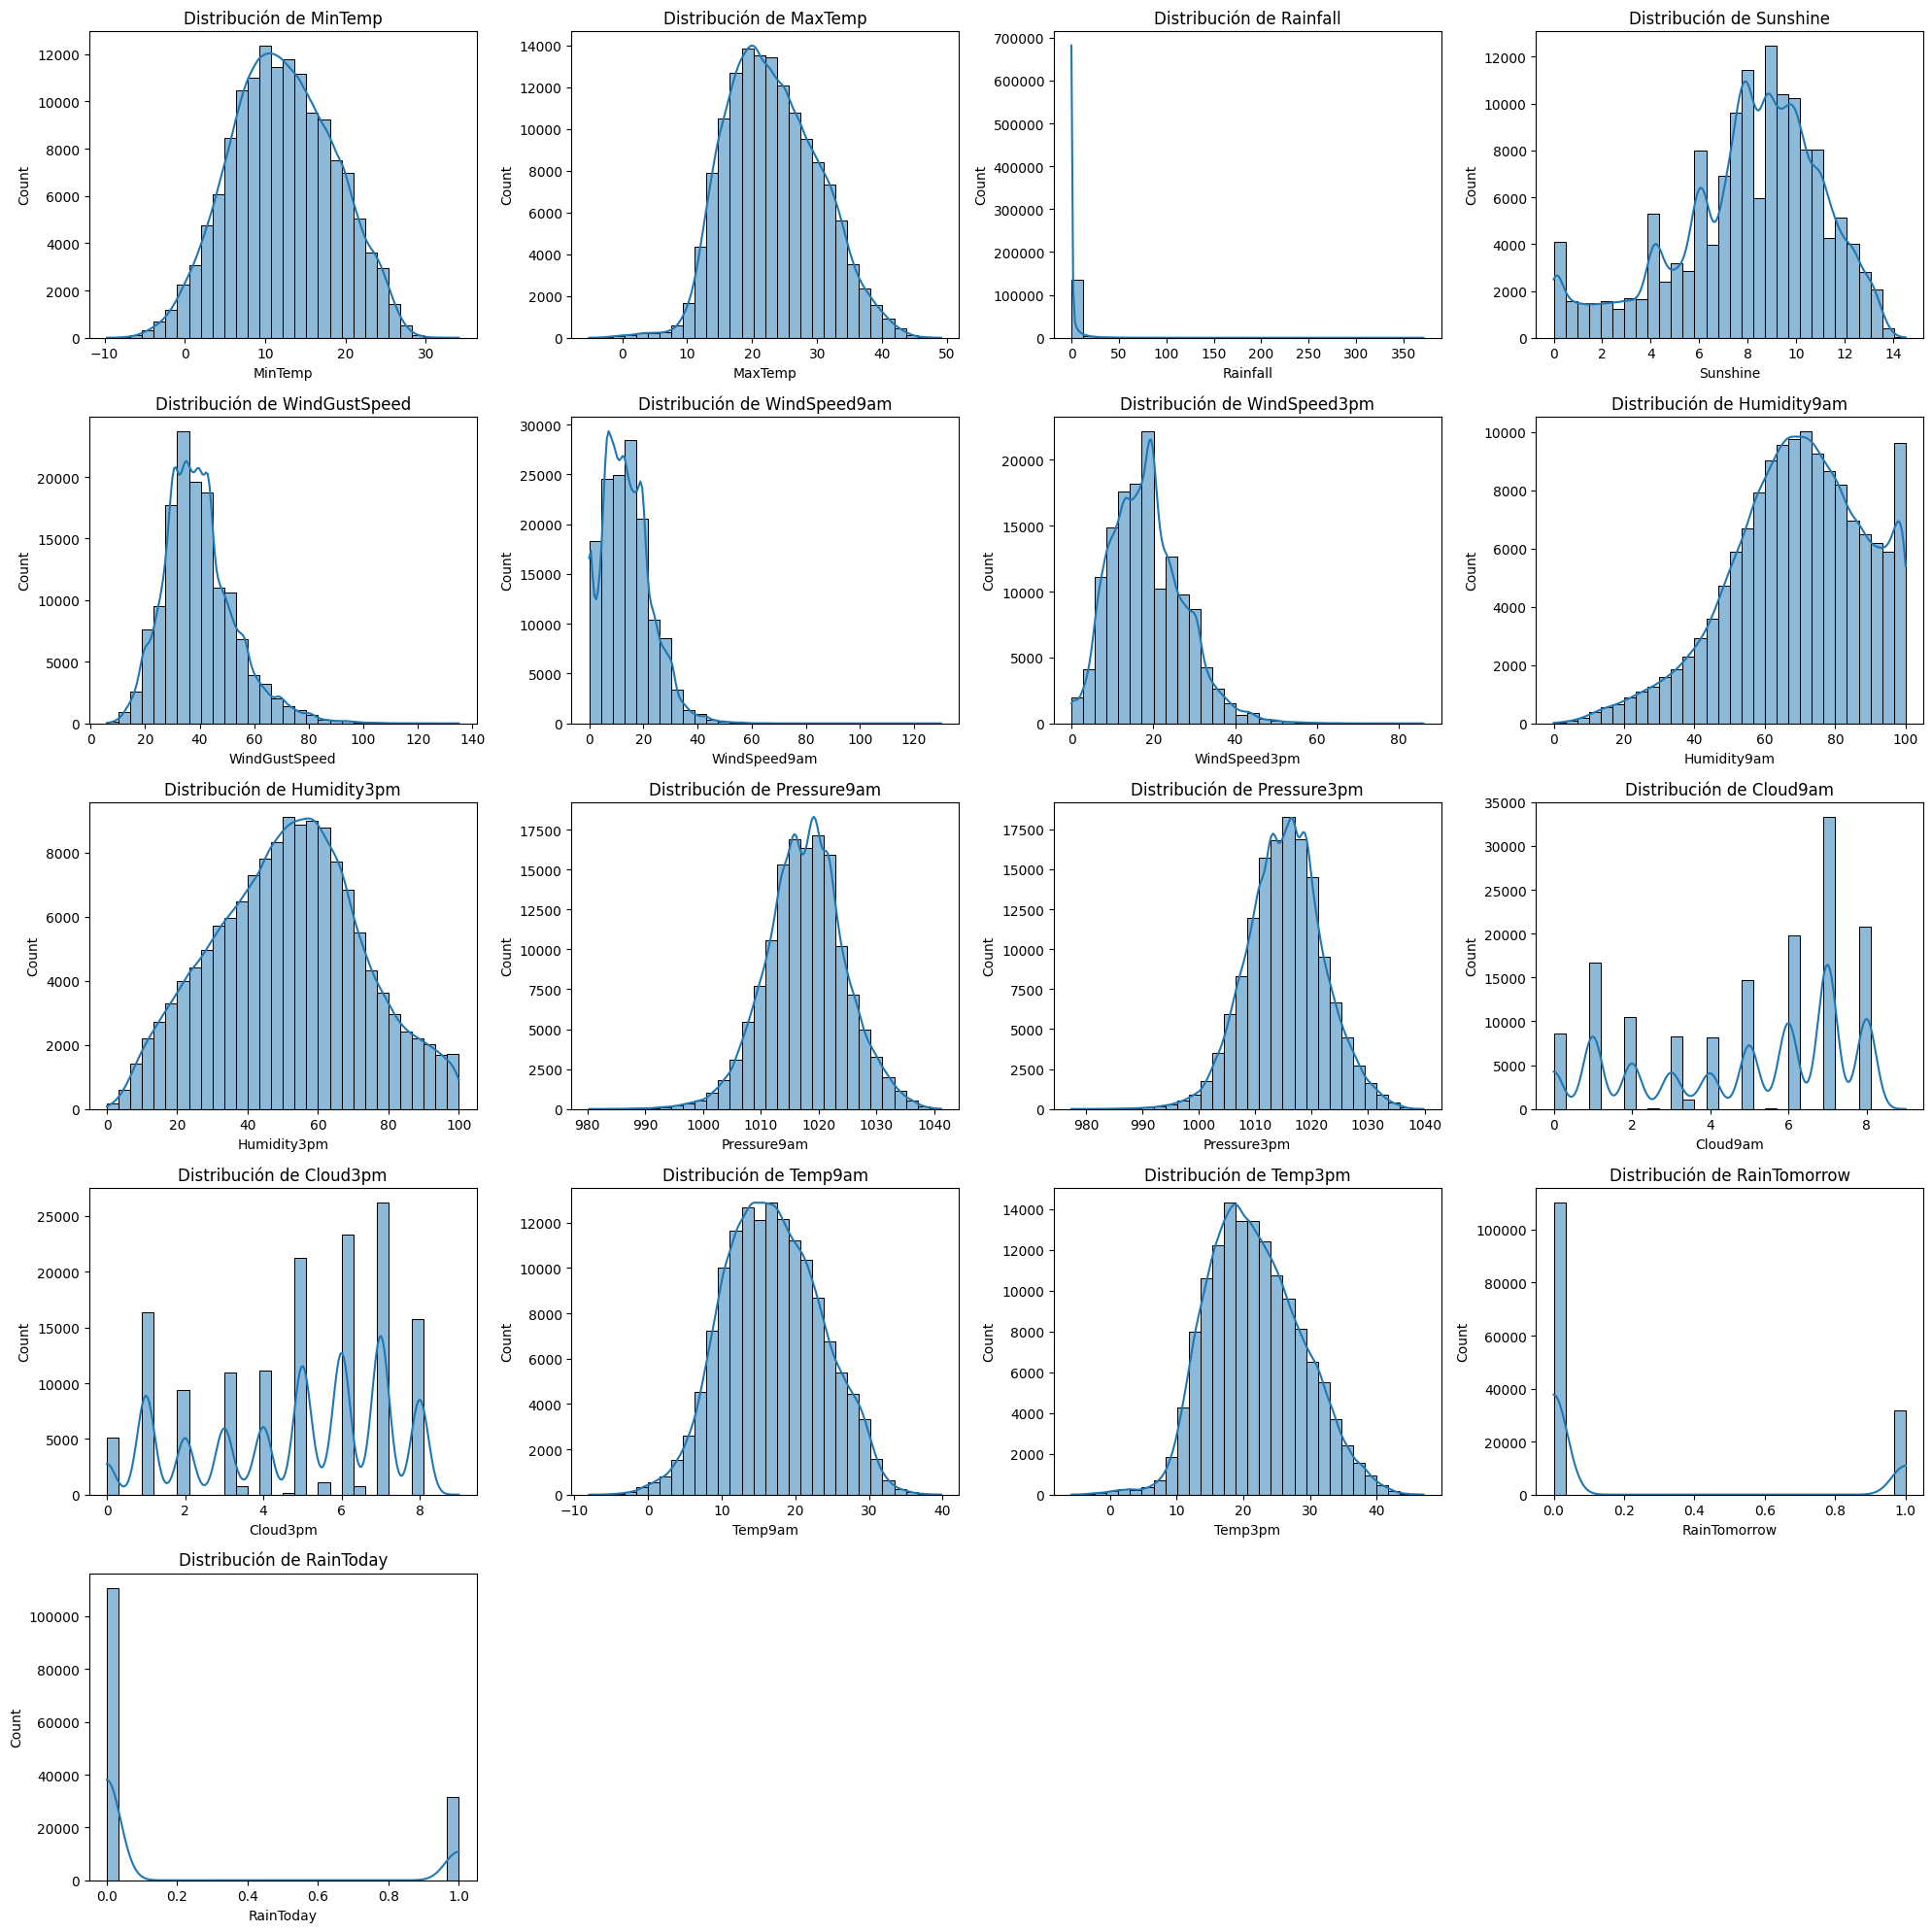

In [269]:
cols_plot = [
    'MinTemp',
    'MaxTemp',
    'Rainfall',
    'Sunshine',
    'WindGustSpeed',
    'WindSpeed9am',
    'WindSpeed3pm',
    'Humidity9am',
    'Humidity3pm',
    'Pressure9am',
    'Pressure3pm',
    'Cloud9am',
    'Cloud3pm',
    'Temp9am',
    'Temp3pm',
    "RainTomorrow",
    "RainToday"
]

n_cols = 4
n_rows = math.ceil(len(cols_plot) / n_cols)

plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(cols_plot, 1):

    plt.subplot(n_rows, n_cols, i)

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

Las distribuciones muestran que varias variables climáticas presentan comportamientos esperables y útiles para el análisis predictivo. Las temperaturas (`MinTemp`, `MaxTemp`, `Temp9am`, `Temp3pm`) y las presiones (`Pressure9am`, `Pressure3pm`) tienen distribuciones relativamente concentradas y con forma aproximadamente campanular, aunque con cierta asimetría. En cambio, variables como `Rainfall`, `Evaporation`, `WindGustSpeed` y velocidades de viento presentan sesgo hacia la derecha, con muchos valores bajos y pocos valores extremos, lo que sugiere la presencia de eventos climáticos intensos pero poco frecuentes. Las variables de nubosidad (`Cloud9am`, `Cloud3pm`) muestran valores discretos, ya que representan niveles de cobertura nubosa, mientras que `RainToday` y `RainTomorrow` evidencian claramente el desbalance de clases: predominan ampliamente los días sin lluvia. Este desbalance debe tenerse en cuenta al evaluar modelos, ya que métricas como accuracy pueden resultar engañosas si no se complementan con recall, precision, F1-score y balanced accuracy.

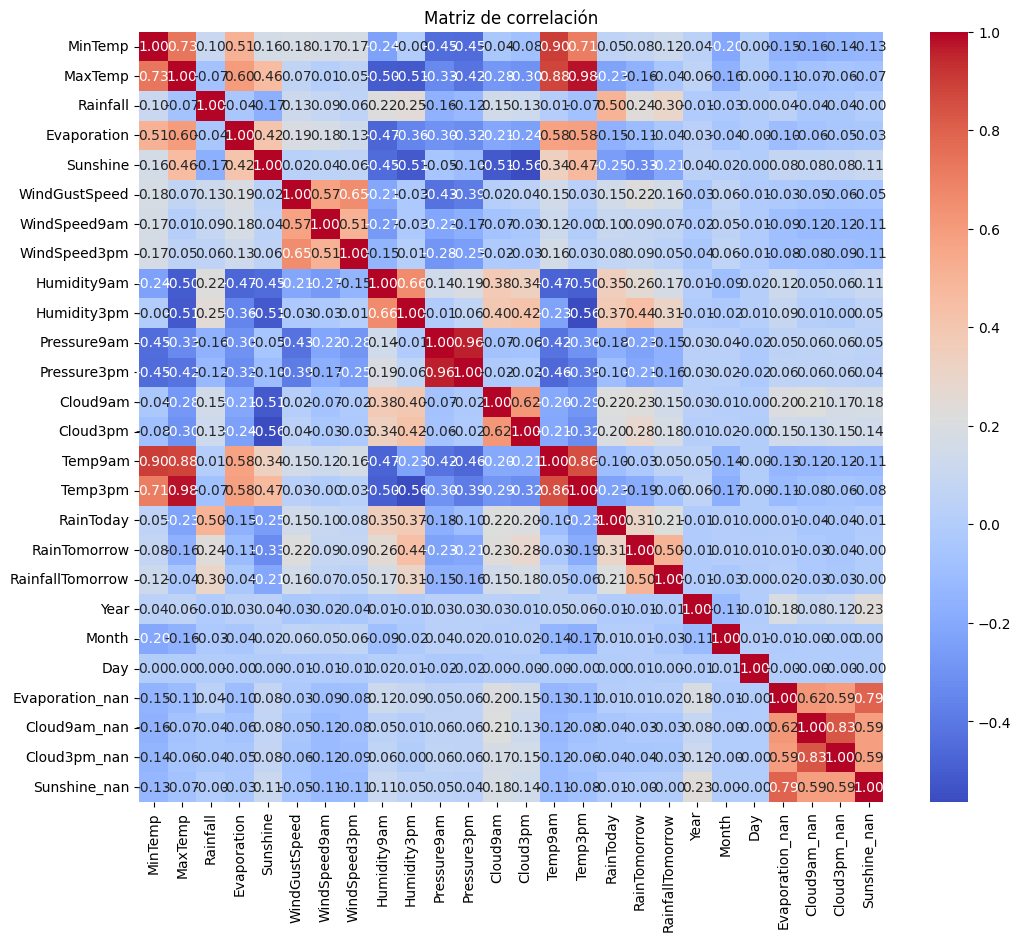

In [270]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()

La matriz de correlación permitió identificar relaciones lineales fuertes entre variables medidas en distintos horarios del día, especialmente en temperatura y presión atmosférica, indicando posibles problemas de multicolinealidad y redundancia de información, sin embargo, dichas relaciones resultan físicamente coherentes. Se observaron asociaciones relevantes entre humedad, nubosidad y horas de sol, consistentes con el comportamiento esperado de fenómenos atmosféricos relacionados con precipitaciones.

In [271]:
cols_numericas = df.select_dtypes(include="number").columns

cols_predictores = cols_numericas.drop("RainTomorrow", errors="ignore")

corr = df[cols_predictores].corr()

mask = np.triu(np.ones(corr.shape), k=1).astype(bool)

tabla_corr = (
    corr.where(mask)
    .stack()
    .reset_index()
)

tabla_corr.columns = ["Variable 1", "Variable 2", "Correlación"]

tabla_corr["Correlación absoluta"] = tabla_corr["Correlación"].abs()

tabla_corr = tabla_corr.sort_values(
    "Correlación absoluta",
    ascending=False
)

tabla_corr.head(15)

,Variable 1,Variable 2,Correlación,Correlación absoluta
36,MaxTemp,Temp3pm,0.977979,0.977979
221,Pressure9am,Pressure3pm,0.958949,0.958949
14,MinTemp,Temp9am,0.896753,0.896753
35,MaxTemp,Temp9am,0.882539,0.882539
309,Temp9am,Temp3pm,0.857427,0.857427
1,MinTemp,MaxTemp,0.732723,0.732723
15,MinTemp,Temp3pm,0.708449,0.708449
177,Humidity9am,Humidity3pm,0.662649,0.662649
112,WindGustSpeed,WindSpeed3pm,0.652404,0.652404
265,Cloud9am,Cloud3pm,0.618718,0.618718


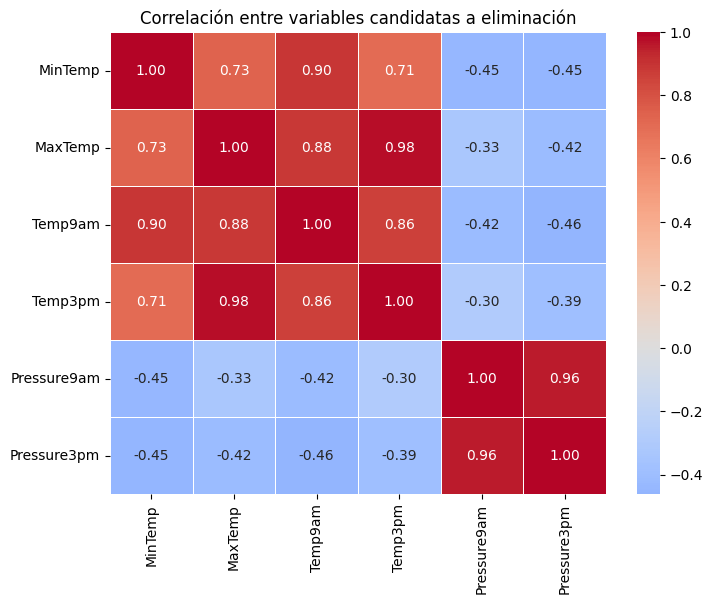

In [272]:
cols_redundancia = [
    "MinTemp",
    "MaxTemp",
    "Temp9am",
    "Temp3pm",
    "Pressure9am",
    "Pressure3pm"
]

cols_redundancia = [
    col for col in cols_redundancia
    if col in df.columns
]

corr_redundancia = df[cols_redundancia].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_redundancia,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlación entre variables candidatas a eliminación")
plt.show()

A partir de la matriz de correlación general se identificaron pares de variables numéricas con alta asociación lineal. Para complementar la visualización, se construyó una tabla ordenada por correlación absoluta, lo que permite observar de forma directa los pares de predictores con mayor redundancia.

En particular, `Pressure9am` y `Pressure3pm` presentan una correlación de aproximadamente 0.96, por lo que se decidió conservar `Pressure3pm` y eliminar `Pressure9am`, reduciendo información repetida dentro del conjunto de entrada. De forma similar, `MinTemp`, `MaxTemp` y `Temp3pm`  presentan una alta correlación con otras variables de temperatura, por lo que se decidió dejar sólo una para simplificar el modelo y reducir redundancia entre predictores.

Esta decisión no implica que `Temp9am` o `Pressure9am` no estén relacionadas con la lluvia al día siguiente, sino que parte de su información ya está representada por otras variables conservadas. El objetivo es obtener un conjunto de variables más simple e interpretable, evitando incluir múltiples predictores que describen fenómenos muy similares.

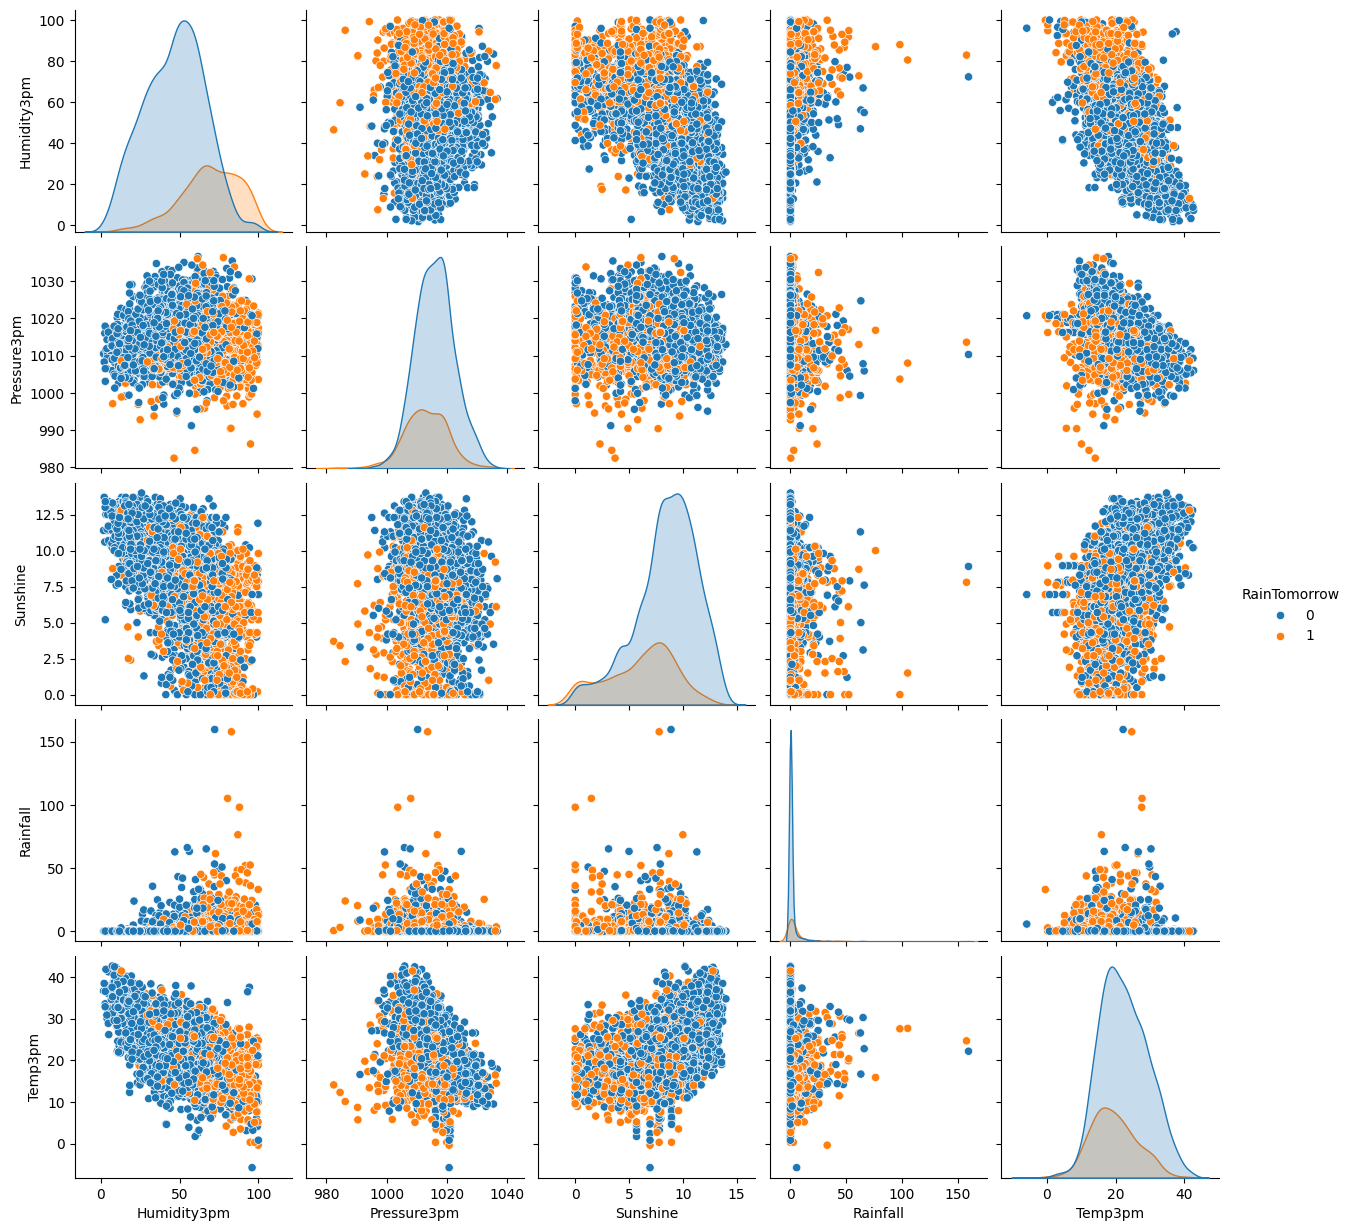

In [273]:
pair_cols = [
    "Humidity3pm",
    "Pressure3pm",
    "Sunshine",
    "Rainfall",
    "Temp3pm",
    "RainTomorrow"
]

sns.pairplot(
    df[pair_cols].sample(3000),
    hue="RainTomorrow"
)

El análisis del pairplot permitió identificar relaciones relevantes entre las variables meteorológicas y la variable objetivo (`RainTomorrow`). Variables como `Humidity3pm`, `Pressure3pm` y `Sunshine` muestran una separación visual clara entre clases, indicando un alto potencial predictivo. En particular, los casos asociados a lluvia futura presentan mayores niveles de humedad, menores niveles de presión atmosférica y menor cantidad de horas de sol. Además, se observaron relaciones coherentes entre variables, como la relación inversa entre humedad y sunshine, y distribuciones altamente asimétricas en variables como `Rainfall`, comportamiento esperable en fenómenos climáticos reales.

Se considera importante no eliminar los Outliers en este dataset ya que si bien algunos datos pueden alejarse del comportamiento normal de los datos, siguen siendo casos reales de condiciones climaticas y es necesario que el modela sepa que hacer en caso de que ellos se repitan.

In [274]:
df["Rainfall_log"] = np.log1p(df["Rainfall"])

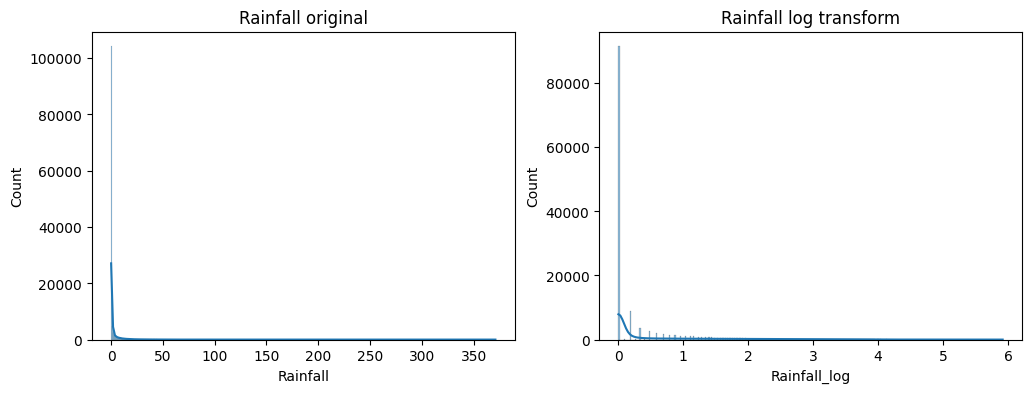

In [275]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df["Rainfall"], kde=True, ax=ax[0])
ax[0].set_title("Rainfall original")

sns.histplot(df["Rainfall_log"], kde=True, ax=ax[1])
ax[1].set_title("Rainfall log transform")

plt.show()

Se aplica una transformación Logaritmica a la variable para reducir el rango de trabajo.

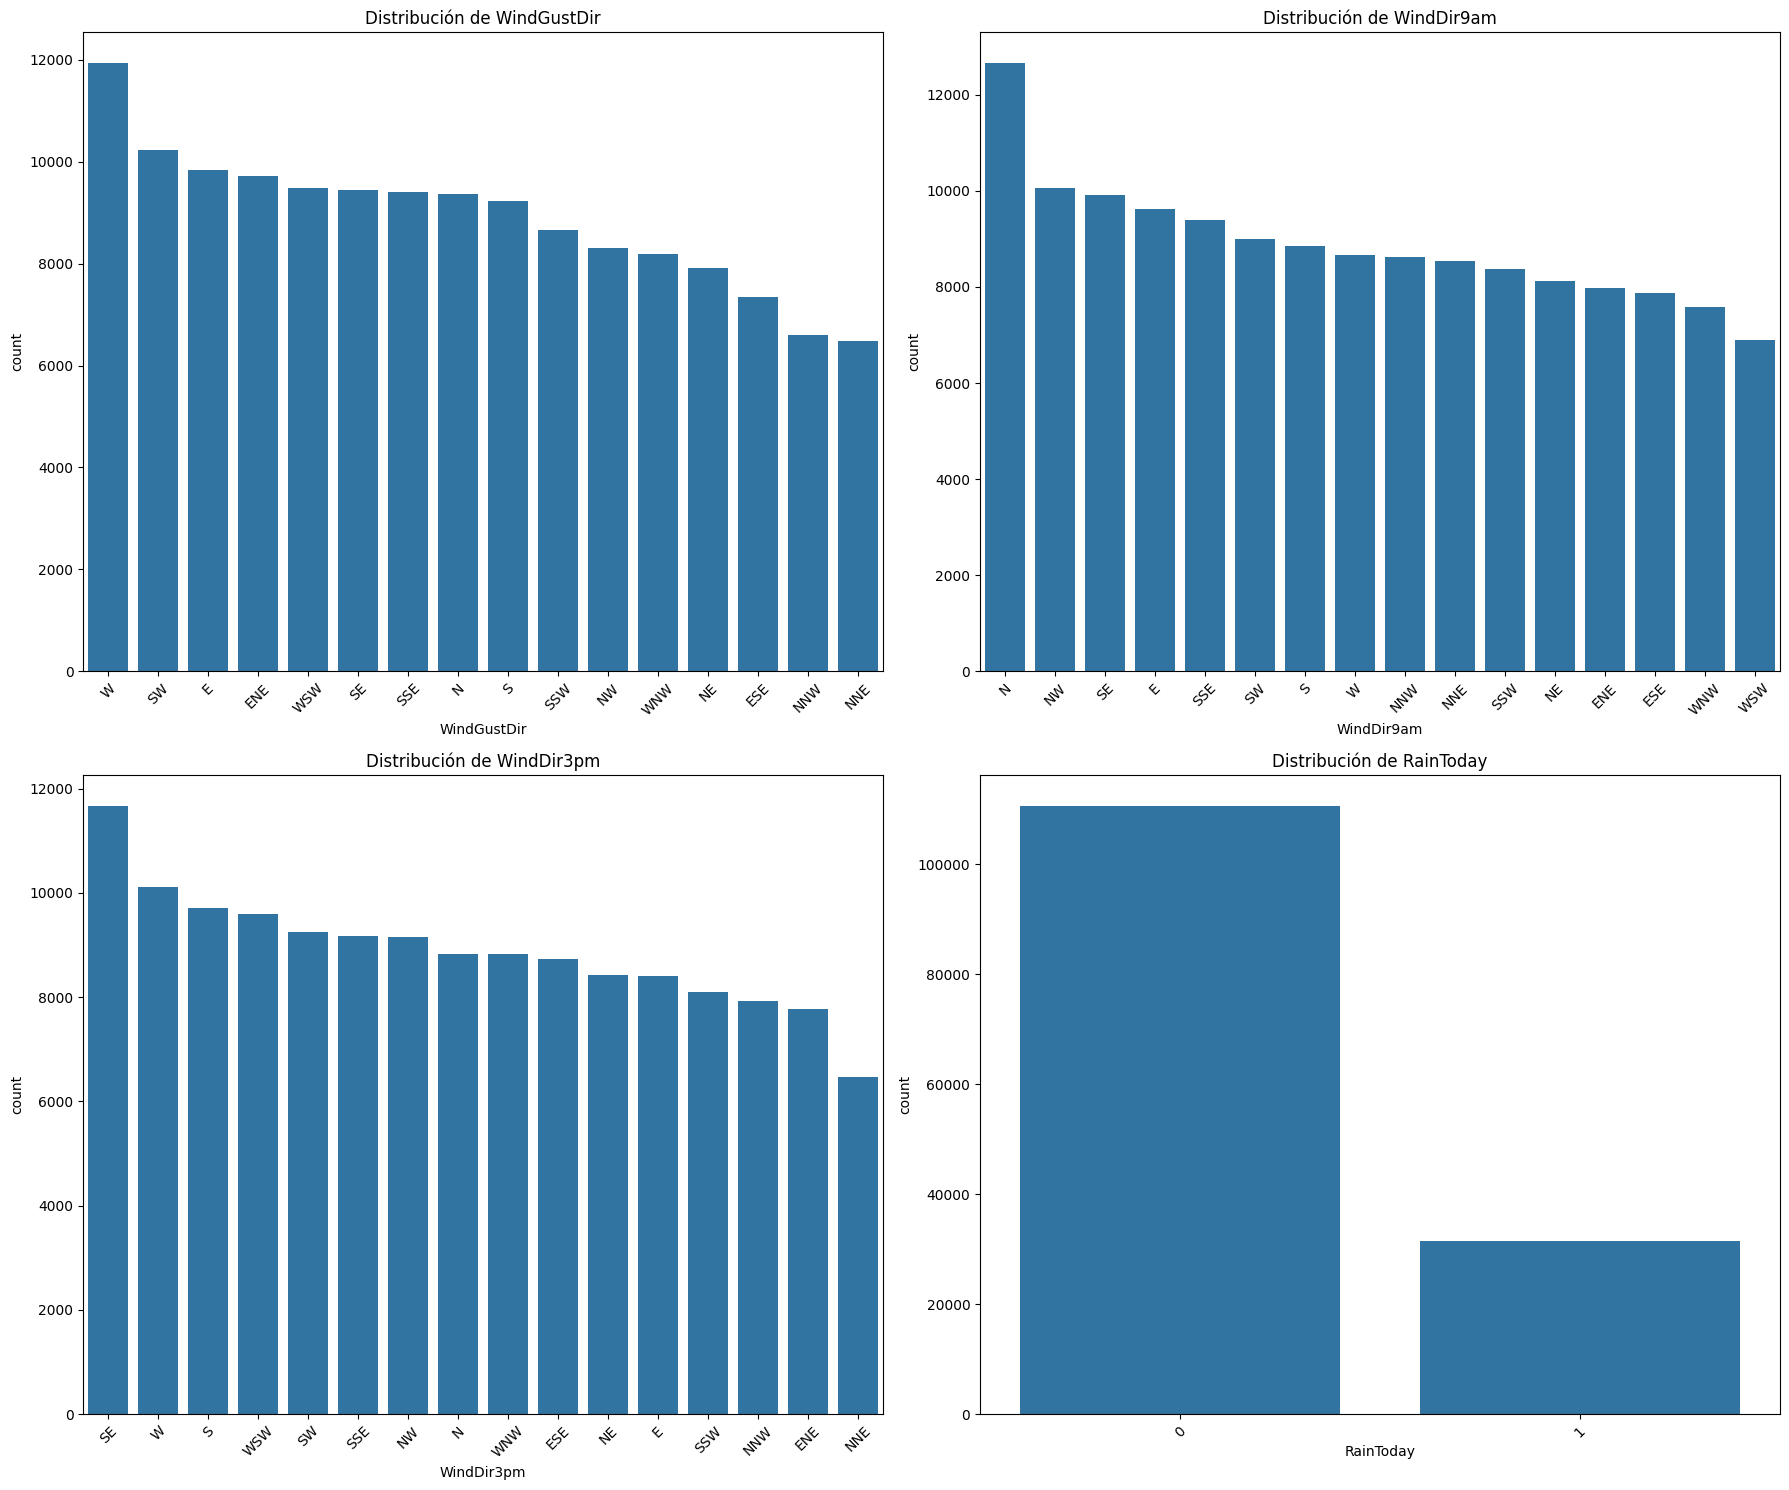

In [276]:
fig, axes = plt.subplots(2, 2, figsize=(18,15))

axes = axes.flatten()

for ax, col in zip(axes, cols_categoricas):

    sns.countplot(
        data=df,
        x=col,
        ax=ax,
        order=df[col].value_counts().index
    )

    ax.set_title(f"Distribución de {col}")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

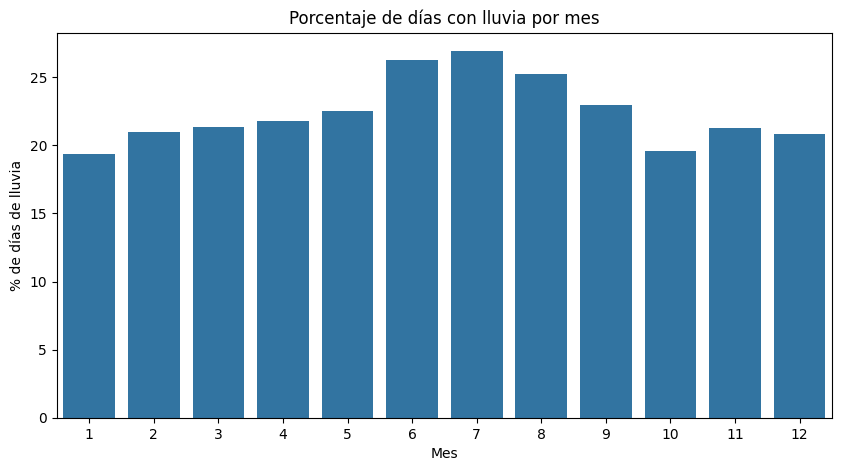

In [277]:
rain_month = (
    df.groupby("Month")["RainTomorrow"]
    .mean()
    .mul(100)
    .reset_index(name="% RainTomorrow = 1")
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=rain_month,
    x="Month",
    y="% RainTomorrow = 1"
)

plt.title("Porcentaje de días con lluvia por mes")
plt.xlabel("Mes")
plt.ylabel("% de días de lluvia")
plt.show()

Cómo era de esperarse, hay una relación marcada entre lluvia y estación del año.

Con esto se finalizó el EDA. Lo primero que se hizo fué observar superficialmente los datos para tratar de encontrar problemas en el Dataset, se terminó observando que había una gran cantidad de NaN, al investigar un poco se llegó a la conclusión de que el motivo de los faltantes está directamente relacionado a la tecnología disponible por cada observatorio. Para poder imputar los datos faltantes se implementó un criterio de Imputación por lugar o vecinos, que refiere a, en los casos dónde hay pocos faltantes, usar la media de la variable en ese lugar y ese mes para poder usar de referencia una media que entienda las diferencias geograficas y de tiempo para cada valor, ya que no sería justo comparar la media de temperatura máxima en Junio al sur que la media en Agosto al norte. El segundo criterio que se empleó, para los casos dónde no se tiene ningún dato en todo el mes, ya que el observatorio no es capaz de medir esa variable, es un criterio de "vecinos cercanos", que usando de referencia la ubicación geografica de cada observatorio arma un calendario de vecinos y usa una media entre los valores de la media en ese mes del nan de los alrededores para estimar un valor posible para el faltante.  Con estos métodos se pudieron imputar todos los ausentes sin alterar demasiado las métricas del dataset.

In [278]:
col_drop = [
    "Evaporation",
    "RainfallTomorrow",
    "Rainfall",
    "MaxTemp",
    "Temp9am",
    "Pressure9am",
    "Evaporation_nan",
    "Cloud9am_nan",
    "Cloud3pm_nan",
    "Sunshine_nan",
    "Day",
    "Year"]

df_model = df.drop(columns=col_drop)
df_model

,Location,MinTemp,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure3pm,Cloud9am,Cloud3pm,Temp3pm,RainToday,RainTomorrow,Month,Rainfall_log
0,Albury,13.6,9.8,W,45.0,W,WNW,19.0,25.0,68.8,23.8,1007.2,8.0,5.0,20.8,0,0,12,0.470004
1,Albury,7.3,9.8,WNW,44.0,NNW,WSW,4.0,23.0,40.1,22.1,1007.5,7.0,5.0,24.6,0,0,12,0.000000
2,Albury,13.2,9.8,WSW,46.0,W,WSW,20.0,27.0,36.2,31.5,1009.4,7.0,2.0,23.4,0,0,12,0.000000
3,Albury,10.0,9.8,NE,23.0,SE,E,10.0,10.0,45.8,18.5,1012.4,7.0,5.0,26.3,0,0,12,0.000000
4,Albury,17.4,9.8,W,41.0,ENE,NW,6.0,17.0,83.5,34.6,1005.9,7.0,8.0,29.1,0,0,12,0.693147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145407,Uluru,2.6,7.5,E,29.0,ESE,E,14.0,11.0,58.6,26.5,1021.2,6.0,3.0,21.6,0,0,6,0.000000
145408,Uluru,3.1,7.5,E,31.0,SE,ENE,14.0,10.0,51.9,24.7,1020.5,6.0,3.0,21.5,0,0,6,0.000000
145409,Uluru,3.6,7.5,NNW,21.0,SE,N,13.0,6.0,56.5,21.4,1018.4,6.0,3.0,24.5,0,0,6,0.000000
145410,Uluru,4.8,7.5,N,39.0,SE,WNW,10.0,8.0,52.5,23.7,1016.0,6.0,3.0,26.9,0,0,6,0.000000


Basandose en la matriz de correlación se considera que estas vars pueden meter ruido al modelo por la gran correlación entre las var a las 9am y las 3pm, nos quedaremos directamente con las últimas.  
Ademá se opta por eliminar evaporation, por lo mencionado antes, Rainfall, porque ya se ha hecho una nueva versión transformada y los indicadores de nan.  
Tambien se elimina RainfallTomorrow porque si intentamos predecir si va a llover o no mañana, no tendría sentido usar la información sobre cantidad de lluvia de mañana, ya que se supone que no lo sabemos.  
Y por último, se eliminan Day y Year ya que no hay relación directa entre día del mes y año con el clima, y mantener esssa información podría llevar a que el modelo encuentre relaciones ficticias entre esos datos. Month se deja ya que el mes del año si hace alución a la estación del año y tiene relación con tendencias climaticas.

In [279]:
X = df_model.drop(columns=["RainTomorrow"])
y = df_model["RainTomorrow"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

se hace el split de datos en train, test y validation

In [280]:
cat_cols = [
    "Location",
    "WindGustDir",
    "WindDir9am",
    "WindDir3pm",
    "Month"
]

ohe = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

# Se ajusta SOLO con train
X_train_encoded = ohe.fit_transform(X_train[cat_cols])

# Se transforma validation y test con el encoder ya ajustado
X_val_encoded = ohe.transform(X_val[cat_cols])
X_test_encoded = ohe.transform(X_test[cat_cols])

encoded_cols = ohe.get_feature_names_out(cat_cols)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols,
    index=X_train.index
)

X_val_encoded = pd.DataFrame(
    X_val_encoded,
    columns=encoded_cols,
    index=X_val.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols,
    index=X_test.index
)

X_train = pd.concat(
    [
        X_train.drop(columns=cat_cols),
        X_train_encoded
    ],
    axis=1
)

X_val = pd.concat(
    [
        X_val.drop(columns=cat_cols),
        X_val_encoded
    ],
    axis=1
)

X_test = pd.concat(
    [
        X_test.drop(columns=cat_cols),
        X_test_encoded
    ],
    axis=1
)

Las variables categóricas nominales (`Location`, `WindGustDir`, `WindDir9am` y `WindDir3pm`) fueron transformadas mediante One Hot Encoding utilizando `OneHotEncoder` de Scikit-Learn. Este método genera una columna binaria para cada categoría presente en la variable, permitiendo representar información categórica en modelos matemáticos sin introducir relaciones ordinales artificiales entre categorías. Se utilizó `drop='first'` para evitar redundancia y reducir posibles problemas de multicolinealidad.

In [281]:
# se separan las columnas entre Standard y Robust
standard_cols = [
    "MinTemp",
    "Temp3pm",
    "Pressure3pm",
    "Humidity9am",
    "Humidity3pm",
    "Sunshine"
]

robust_cols = [
    "Rainfall_log",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm"
]

standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

X_train[standard_cols] = standard_scaler.fit_transform(
    X_train[standard_cols]
)

X_val[standard_cols] = standard_scaler.transform(
    X_val[standard_cols]
)

X_test[standard_cols] = standard_scaler.transform(
    X_test[standard_cols]
)

X_train[robust_cols] = robust_scaler.fit_transform(
    X_train[robust_cols]
)

X_val[robust_cols] = robust_scaler.transform(
    X_val[robust_cols]
)

X_test[robust_cols] = robust_scaler.transform(
    X_test[robust_cols]
)

X_train.head()

,MinTemp,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure3pm,Cloud9am,Cloud3pm,...,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
57764,-1.175968,-1.288890,1.5625,2.583333,0.500000,1.605852,2.332890,-1.268989,8.0,7.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
31606,1.048240,0.015415,0.4375,0.250000,0.666667,0.118026,0.487057,-0.410278,6.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42226,-1.331507,0.602353,-0.0625,1.500000,-0.583333,-0.924500,-1.069611,0.344796,3.0,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
38451,-0.538258,-0.571522,-0.5000,-0.500000,0.083333,1.385822,0.684653,-0.173392,8.0,4.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
33683,-0.304950,0.504530,-1.0000,-0.166667,-0.666667,0.207086,0.284642,0.152326,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


Las variables numéricas fueron escaladas utilizando distintos métodos según su distribución. Para variables con comportamiento aproximadamente normal se utilizó `StandardScaler`, que centra los datos en media 0 y desviación estándar 1. En variables con fuerte asimetría y presencia de outliers, como precipitaciones y velocidades de viento, se utilizó `RobustScaler`, basado en mediana e IQR, reduciendo la sensibilidad a valores extremos. Los escaladores fueron ajustados únicamente sobre el conjunto de entrenamiento para evitar data leakage.

In [304]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [305]:
y_pred_train = log_reg.predict(X_train)
y_pred_val = log_reg.predict(X_val)
y_pred_test = log_reg.predict(X_test)

y_proba_train = log_reg.predict_proba(X_train)[:, 1]
y_proba_val = log_reg.predict_proba(X_val)[:, 1]
y_proba_test = log_reg.predict_proba(X_test)[:, 1]

In [306]:
def resumen_metricas_clasificacion(nombre, y_true, y_pred, y_proba):

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return pd.DataFrame({
        "Modelo": [nombre],

        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Balanced Accuracy": [balanced_accuracy_score(y_true, y_pred)],

        "Precision": [precision_score(y_true, y_pred, zero_division=0)],
        "Recall": [recall_score(y_true, y_pred, zero_division=0)],
        "Specificity": [specificity],
        "F1 Score": [f1_score(y_true, y_pred, zero_division=0)],

        "ROC AUC": [roc_auc_score(y_true, y_proba)],
        "PR AUC / Avg Precision": [average_precision_score(y_true, y_proba)],
        "Brier Score": [brier_score_loss(y_true, y_proba)],

        "MCC": [matthews_corrcoef(y_true, y_pred)],
        "Cohen Kappa": [cohen_kappa_score(y_true, y_pred)],

        "TN": [tn],
        "FP": [fp],
        "FN": [fn],
        "TP": [tp]
    })

In [307]:
print("Reporte de clasificación - Test")
print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=["No llueve", "Llueve"],
        zero_division=0
    )
)

Reporte de clasificación - Test
              precision    recall  f1-score   support

   No llueve       0.92      0.80      0.86     22057
      Llueve       0.52      0.77      0.62      6374

    accuracy                           0.79     28431
   macro avg       0.72      0.78      0.74     28431
weighted avg       0.83      0.79      0.80     28431



In [308]:
metricas_train = resumen_metricas_clasificacion(
    "Regresión Logística - Train",
    y_train,
    y_pred_train,
    y_proba_train
)

metricas_test = resumen_metricas_clasificacion(
    "Regresión Logística - Test",
    y_test,
    y_pred_test,
    y_proba_test
)

tabla_metricas_logreg = pd.concat(
    [metricas_train, metricas_test],
    ignore_index=True
)

tabla_metricas_logreg

,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,ROC AUC,PR AUC / Avg Precision,Brier Score,MCC,Cohen Kappa,TN,FP,FN,TP
0,Regresión Logística - Train,0.794025,0.787323,0.527682,0.775174,0.799473,0.627921,0.871861,0.702663,0.144065,0.509939,0.492526,56426,14153,4586,15812
1,Regresión Logística - Test,0.791812,0.784393,0.524272,0.770944,0.797842,0.624119,0.871408,0.703128,0.144231,0.504604,0.487279,17598,4459,1460,4914


Se calculan métricas clásicas de clasificación y métricas adicionales. Debido al desbalance de clases, no se utiliza únicamente accuracy, sino también balanced accuracy, precision, recall, F1, ROC-AUC y Average Precision. Además, se incorporan MCC y Cohen's Kappa como métricas complementarias para evaluar la calidad global de la clasificación.

In [309]:
fpr_val, tpr_val, thresholds_roc_val = roc_curve(y_val, y_proba_val)

youden_index = tpr_val - fpr_val
best_idx_youden = np.argmax(youden_index)
best_threshold_youden = thresholds_roc_val[best_idx_youden]

precision_val, recall_val, thresholds_pr_val = precision_recall_curve(
    y_val,
    y_proba_val
)

f1_scores = 2 * (precision_val * recall_val) / (precision_val + recall_val)

best_idx_f1 = np.nanargmax(f1_scores[:-1])
best_threshold_f1 = thresholds_pr_val[best_idx_f1]

print(f"Mejor umbral según Youden en validación: {best_threshold_youden:.4f}")
print(f"Mejor umbral según F1 en validación: {best_threshold_f1:.4f}")
print(f"F1 en validación: {f1_scores[best_idx_f1]:.4f}")

Mejor umbral según Youden en validación: 0.5239
Mejor umbral según F1 en validación: 0.6082
F1 en validación: 0.6402


In [310]:
threshold_elegido = best_threshold_f1

y_pred_train_logreg_final = (y_proba_train >= threshold_elegido).astype(int)
y_pred_val_logreg_final = (y_proba_val >= threshold_elegido).astype(int)
y_pred_test_logreg_final = (y_proba_test >= threshold_elegido).astype(int)

print(f"Umbral elegido para Regresión Logística: {threshold_elegido:.4f}")

Umbral elegido para Regresión Logística: 0.6082


In [311]:
metricas_logreg_final_train = resumen_metricas_clasificacion(
    "Regresión Logística - Train - Umbral F1",
    y_train,
    y_pred_train_logreg_final,
    y_proba_train
)

metricas_logreg_final_test = resumen_metricas_clasificacion(
    "Regresión Logística - Test - Umbral F1",
    y_test,
    y_pred_test_logreg_final,
    y_proba_test
)

tabla_metricas_logreg_final = pd.concat(
    [metricas_logreg_final_train, metricas_logreg_final_test],
    ignore_index=True
)

tabla_metricas_logreg_final

,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,ROC AUC,PR AUC / Avg Precision,Brier Score,MCC,Cohen Kappa,TN,FP,FN,TP
0,Regresión Logística - Train - Umbral F1,0.827121,0.778173,0.599548,0.689430,0.866915,0.641355,0.871861,0.702663,0.144065,0.530432,0.528195,61186,9393,6335,14063
1,Regresión Logística - Test - Umbral F1,0.823503,0.774476,0.591820,0.685598,0.863354,0.635267,0.871408,0.703128,0.144231,0.522123,0.519677,19043,3014,2004,4370


In [312]:
umbrales = {
    "Regresión Logística - Umbral 0.5": 0.5,
    "Regresión Logística - Umbral Youden": best_threshold_youden,
    "Regresión Logística - Umbral F1": best_threshold_f1
}

resultados_umbrales = []

for nombre, threshold in umbrales.items():
    y_pred_umbral = (y_proba_test >= threshold).astype(int)

    resultados_umbrales.append(
        resumen_metricas_clasificacion(
            nombre,
            y_test,
            y_pred_umbral,
            y_proba_test
        )
    )

tabla_umbrales = pd.concat(resultados_umbrales, ignore_index=True)

tabla_umbrales

,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,ROC AUC,PR AUC / Avg Precision,Brier Score,MCC,Cohen Kappa,TN,FP,FN,TP
0,Regresión Logística - Umbral 0.5,0.791812,0.784393,0.524272,0.770944,0.797842,0.624119,0.871408,0.703128,0.144231,0.504604,0.487279,17598,4459,1460,4914
1,Regresión Logística - Umbral Youden,0.800710,0.783770,0.539811,0.753059,0.814481,0.628848,0.871408,0.703128,0.144231,0.510534,0.497649,17965,4092,1574,4800
2,Regresión Logística - Umbral F1,0.823503,0.774476,0.591820,0.685598,0.863354,0.635267,0.871408,0.703128,0.144231,0.522123,0.519677,19043,3014,2004,4370


Se evaluaron distintos umbrales de decisión porque el valor 0.5 no necesariamente es el más adecuado. Al bajar el umbral, el modelo clasifica más observaciones como `Llueve`, lo que suele aumentar el recall, pero también puede aumentar los falsos positivos y reducir la precisión.

El criterio de Youden busca maximizar la diferencia entre la tasa de verdaderos positivos y la tasa de falsos positivos. Por otro lado, el umbral F1 busca el mejor equilibrio entre precision y recall para la clase positiva.

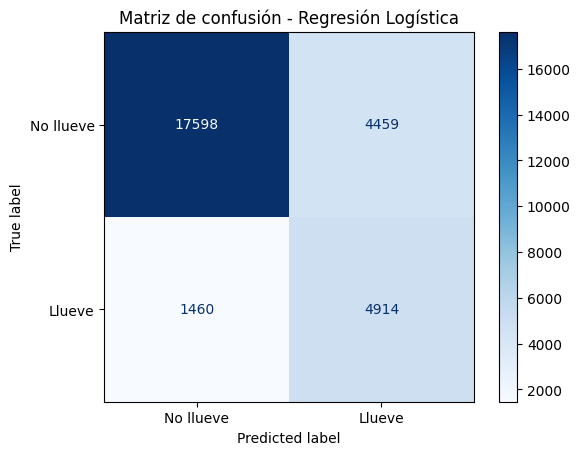

In [313]:
cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No llueve", "Llueve"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

La matriz de confusión permite analizar los aciertos y errores del modelo. Los verdaderos negativos corresponden a días en los que el modelo predijo `No llueve` y efectivamente no llovió. Los verdaderos positivos corresponden a días en los que el modelo predijo `Llueve` y efectivamente llovió.

Un falso positivo ocurre cuando el modelo predice lluvia, pero finalmente no llueve. En cambio, un falso negativo ocurre cuando el modelo predice que no lloverá, pero sí llueve. En este problema, los falsos negativos son especialmente relevantes porque implican no anticipar un evento de lluvia.

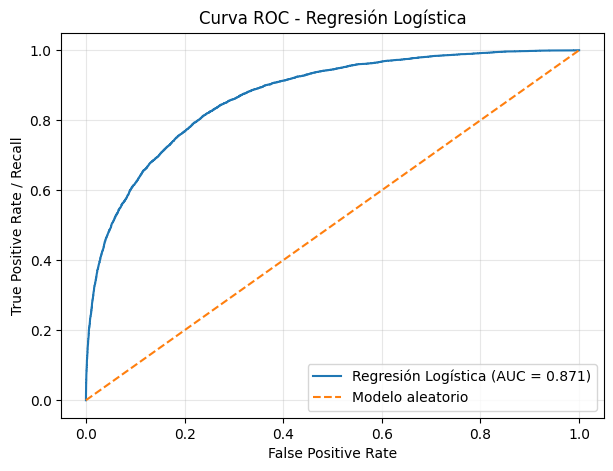

In [314]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Regresión Logística (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Modelo aleatorio")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

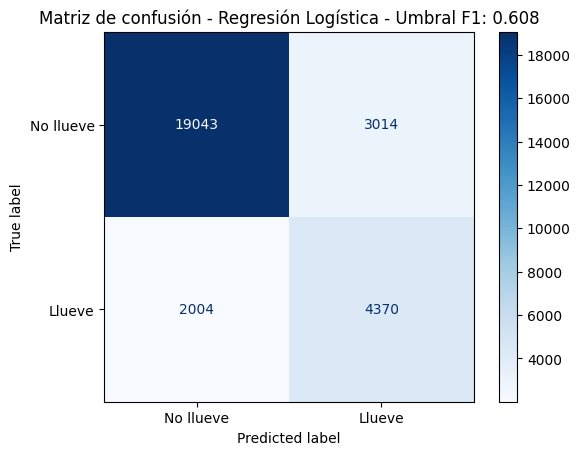

In [315]:
threshold_elegido = best_threshold_f1

y_pred_test_f1 = (y_proba_test >= threshold_elegido).astype(int)

cm_f1 = confusion_matrix(y_test, y_pred_test_f1)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_f1,
    display_labels=["No llueve", "Llueve"]
)

disp.plot(cmap="Blues")
plt.title(f"Matriz de confusión - Regresión Logística - Umbral F1: {threshold_elegido:.3f}")
plt.show()

In [316]:
print("Reporte de clasificación - Test - Umbral mejor F1")
print(
    classification_report(
        y_test,
        y_pred_test_f1,
        target_names=["No llueve", "Llueve"],
        zero_division=0
    )
)

Reporte de clasificación - Test - Umbral mejor F1
              precision    recall  f1-score   support

   No llueve       0.90      0.86      0.88     22057
      Llueve       0.59      0.69      0.64      6374

    accuracy                           0.82     28431
   macro avg       0.75      0.77      0.76     28431
weighted avg       0.83      0.82      0.83     28431



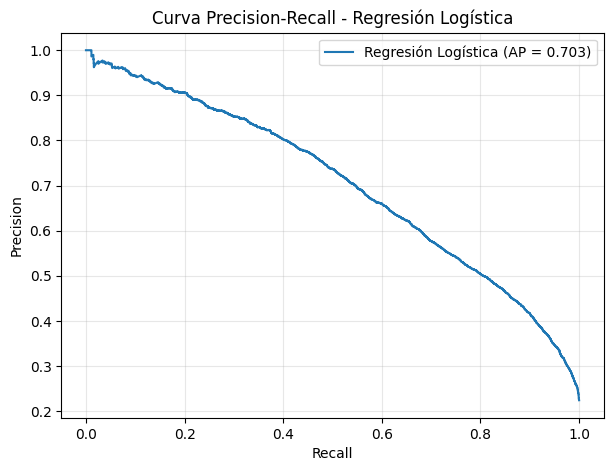

In [317]:
precision_log, recall_log, _ = precision_recall_curve(y_test, y_proba_test)
ap_log = average_precision_score(y_test, y_proba_test)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_log,
    precision_log,
    label=f"Regresión Logística (AP = {ap_log:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Regresión Logística")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Se incorpora la curva Precision-Recall porque el dataset presenta desbalance entre clases. Esta curva permite analizar la relación entre precision y recall para la clase positiva (`Llueve`). A diferencia de la curva ROC, se enfoca directamente en el desempeño sobre la clase minoritaria, por lo que resulta especialmente útil para este problema.

La Regresión Logística obtuvo un desempeño estable entre entrenamiento y prueba, por lo que no se observan señales fuertes de sobreajuste. El accuracy en test fue cercano a 0.85, aunque esta métrica debe interpretarse con cuidado debido al desbalance de clases observado previamente.

Al analizar la clase positiva (`Llueve`), el modelo con umbral 0.5 obtuvo una precisión de 0.73 y un recall de 0.51. Esto indica que, cuando el modelo predice lluvia, suele acertar en una proporción considerable de casos, pero también deja sin detectar una parte importante de los días en los que efectivamente llueve.

En la matriz de confusión se observan 1200 falsos positivos y 3109 falsos negativos. En este problema, un falso positivo significa predecir lluvia cuando finalmente no llueve, mientras que un falso negativo significa predecir que no lloverá cuando sí llueve. Este último error puede ser especialmente relevante, ya que implica no anticipar un evento de lluvia.

La curva ROC obtuvo un AUC de 0.871, lo cual indica una buena capacidad del modelo para separar las clases. Sin embargo, el umbral 0.5 no necesariamente es el más adecuado. Al comparar distintos umbrales, el criterio de Youden aumenta considerablemente el recall, aunque reduce la precisión y genera más falsos positivos. El umbral que maximiza F1 ofrece un equilibrio más conveniente entre precisión y recall, por lo que se considera una alternativa más adecuada para este modelo.

In [318]:
modelo_base = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

modelo_base.fit(X_train, y_train)

y_pred_base_train = modelo_base.predict(X_train)
y_pred_base_test = modelo_base.predict(X_test)

y_proba_base_train = modelo_base.predict_proba(X_train)[:, 1]
y_proba_base_test = modelo_base.predict_proba(X_test)[:, 1]

Se implementó un modelo base utilizando `DummyClassifier` con la estrategia `most_frequent`. Este modelo no aprende relaciones entre las variables predictoras y la variable objetivo, sino que predice siempre la clase más frecuente del conjunto de entrenamiento. Su objetivo es servir como referencia mínima para evaluar si los modelos entrenados posteriormente logran superar una regla simple.

In [319]:
metricas_base_train = resumen_metricas_clasificacion(
    "Modelo Base - Train",
    y_train,
    y_pred_base_train,
    y_proba_base_train
)

metricas_base_test = resumen_metricas_clasificacion(
    "Modelo Base - Test",
    y_test,
    y_pred_base_test,
    y_proba_base_test
)

tabla_metricas_base = pd.concat(
    [metricas_base_train, metricas_base_test],
    ignore_index=True
)

tabla_metricas_base

,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,ROC AUC,PR AUC / Avg Precision,Brier Score,MCC,Cohen Kappa,TN,FP,FN,TP
0,Modelo Base - Train,0.775789,0.5,0.0,0.0,1.0,0.0,0.5,0.224211,0.224211,0.0,0.0,70579,0,20398,0
1,Modelo Base - Test,0.775808,0.5,0.0,0.0,1.0,0.0,0.5,0.224192,0.224192,0.0,0.0,22057,0,6374,0


In [320]:
print("Reporte de clasificación - Modelo Base - Test")
print(
    classification_report(
        y_test,
        y_pred_base_test,
        target_names=["No llueve", "Llueve"],
        zero_division=0
    )
)

Reporte de clasificación - Modelo Base - Test
              precision    recall  f1-score   support

   No llueve       0.78      1.00      0.87     22057
      Llueve       0.00      0.00      0.00      6374

    accuracy                           0.78     28431
   macro avg       0.39      0.50      0.44     28431
weighted avg       0.60      0.78      0.68     28431



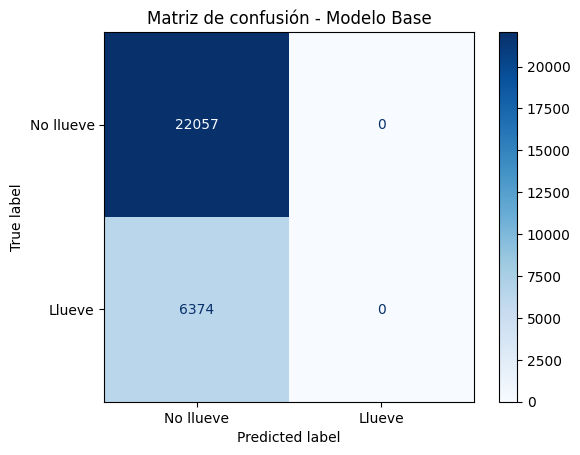

In [321]:
cm_base = confusion_matrix(y_test, y_pred_base_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=["No llueve", "Llueve"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Modelo Base")
plt.show()

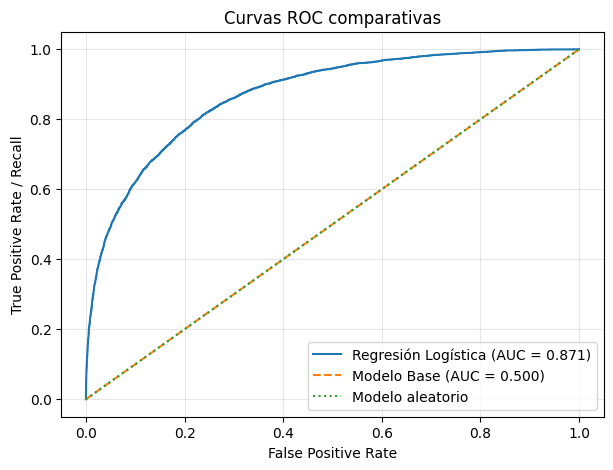

In [322]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_test)
auc_log = roc_auc_score(y_test, y_proba_test)

fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base_test)
auc_base = roc_auc_score(y_test, y_proba_base_test)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Regresión Logística (AUC = {auc_log:.3f})"
)

plt.plot(
    fpr_base,
    tpr_base,
    linestyle="--",
    label=f"Modelo Base (AUC = {auc_base:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    label="Modelo aleatorio"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("Curvas ROC comparativas")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La curva ROC comparativa muestra que el modelo base no tiene capacidad discriminativa, ya que su AUC es 0.5. En cambio, la Regresión Logística alcanza un AUC cercano a 0.871, lo que indica una capacidad considerablemente mayor para separar los casos de lluvia y no lluvia.

In [323]:
comparacion_base = pd.concat(
    [
        tabla_metricas_base[tabla_metricas_base["Modelo"] == "Modelo Base - Test"],
        tabla_metricas_logreg[tabla_metricas_logreg["Modelo"] == "Regresión Logística - Test"],
        tabla_umbrales[tabla_umbrales["Modelo"] == "Regresión Logística - Umbral F1"]
    ],
    ignore_index=True
)

comparacion_base

,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1 Score,ROC AUC,PR AUC / Avg Precision,Brier Score,MCC,Cohen Kappa,TN,FP,FN,TP
0,Modelo Base - Test,0.775808,0.500000,0.000000,0.000000,1.000000,0.000000,0.500000,0.224192,0.224192,0.000000,0.000000,22057,0,6374,0
1,Regresión Logística - Test,0.791812,0.784393,0.524272,0.770944,0.797842,0.624119,0.871408,0.703128,0.144231,0.504604,0.487279,17598,4459,1460,4914
2,Regresión Logística - Umbral F1,0.823503,0.774476,0.591820,0.685598,0.863354,0.635267,0.871408,0.703128,0.144231,0.522123,0.519677,19043,3014,2004,4370


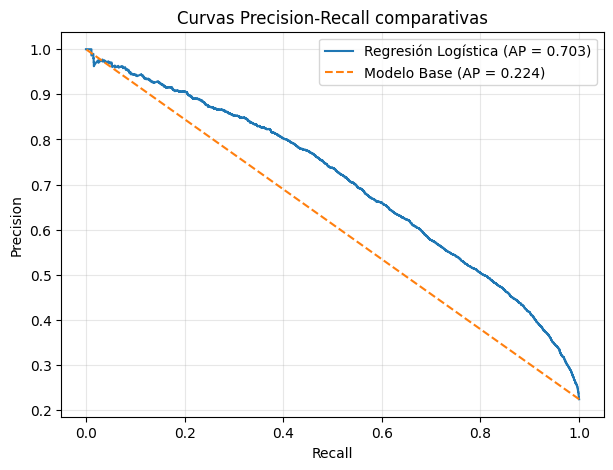

In [324]:
precision_log, recall_log, _ = precision_recall_curve(y_test, y_proba_test)
ap_log = average_precision_score(y_test, y_proba_test)

precision_base, recall_base, _ = precision_recall_curve(y_test, y_proba_base_test)
ap_base = average_precision_score(y_test, y_proba_base_test)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_log,
    precision_log,
    label=f"Regresión Logística (AP = {ap_log:.3f})"
)

plt.plot(
    recall_base,
    precision_base,
    linestyle="--",
    label=f"Modelo Base (AP = {ap_base:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision-Recall comparativas")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

El modelo base obtuvo una accuracy relativamente alta debido al desbalance del dataset, ya que la clase mayoritaria es `No llueve`. Sin embargo, este resultado no implica un buen desempeño predictivo: al predecir siempre la clase mayoritaria, el modelo no logra identificar correctamente los casos de lluvia.

Esto se observa especialmente en el recall y el F1-score de la clase positiva (`Llueve`), que resultan nulos o muy bajos. La matriz de confusión muestra que todos o casi todos los días con lluvia son clasificados como `No llueve`, generando una gran cantidad de falsos negativos.

Por este motivo, el modelo base permite confirmar que la accuracy no es suficiente para evaluar este problema. Dado que el dataset está desbalanceado, es necesario considerar métricas como balanced accuracy, recall, precision, F1-score y ROC-AUC. En comparación, la Regresión Logística mejora claramente el desempeño del modelo base, ya que logra detectar una proporción significativa de días con lluvia y obtiene un AUC superior.